In [2]:
import sys
sys.path.append('../')

from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from src.rset_opt import *
from FasterRisk.src.fasterrisk import fasterrisk
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from method_scripts.results_class import *
from method_scripts.base_method import *

from time import time

In [3]:
for dname, settings in dataset_settings:
    path = f"../datasets/{dname}.csv"
    n_estimators = settings["num_estimators"]
    X_new, y, header, header_new, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, n_estimators)
    print(X_new.shape, y.shape)

(4521, 25) (4521,)
(6907, 22) (6907,)
(768, 50) (768,)
(4601, 30) (4601,)
(24508, 33) (24508,)


In [3]:
def get_all_datasets_results(methods, dataset_names):
    all_datasets_results = {}
    for dname in dataset_names:
        all_columns = set()
        method_dfs = {}
        for method in methods:
            data = load_results(f"../analysis/results/methods/{method}.pkl")
            df = pd.DataFrame(data)
            df = df[df["dataset"] == dname]
            method_dfs[method] = df
            all_columns.update(df.columns)
        all_columns = list(all_columns)

        dfs = []
        for method, df in method_dfs.items():
            df = df.reindex(columns=all_columns)
            df["method"] = method
            dfs.append(df)
        combined_df = pd.concat(dfs, ignore_index=True)
        all_datasets_results[dname] = combined_df 
    return all_datasets_results

def populate_all_datasets_results(all_datasets_results, limit=100):
    for dname, df in all_datasets_results.items():
        print(dname)
        accuracy, logistic, hamming, iou, euclidean, cosine, feature_to_vi = [], [], [], [], [], [], []
        model_count, headers = [], []
        feature_to_shape_diversities = []
        feature_to_shape_differences = []

        path = f"../datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, df.iloc[0]['n_estimators'])
        for i, row in df.iterrows():
            w_rset = row["w_rset"]
            w_opt = row["w_opt"]
            predictions = row["predictions"]
            l2 = 0.001
            print(f"\t{i}: {w_rset.shape[0]}")
            if w_rset.shape[0] > 1000:
                w_rset = w_rset[:1000]
                print(f"\ttruncated to 1000")

            accuracy.append(BaseGAMRSetMethod.get_loss(X, y, w_rset, loss_type="accuracy"))
            logistic.append(BaseGAMRSetMethod.get_loss(X, y, w_rset, loss_type="logistic", l2=l2, sample_p=sample_p))
            hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=limit))

            iou.append(average_pairwise_diversity(w_rset, inverse_IoU, limit=limit))
            euclidean.append(average_pairwise_diversity(w_rset, euclidean_distance, limit=limit))
            cosine.append(average_pairwise_diversity(w_rset, inverse_cosine_similarity, limit=limit))
            model_count.append(w_rset.shape[0])
            headers.append(new_header)

            feature_to_vi.append(get_variable_importance(X, w_rset[:, 1:], np.array(new_header[1:]), True))
            
            # get feature to indices
            feature_to_indices = defaultdict(list)
            feature_to_widths = defaultdict(list)
            feature_ranges = get_feature_ranges(np.array(new_header[1:]))
            for feature, ranges in feature_ranges.items():
                for r in ranges:
                    if len(r) == 1:
                        feature_to_widths[feature].append(r[0])
                    else:
                        feature_to_widths[feature].append(r[1] - r[0])
            for i, col in enumerate(new_header[1:]):
                match = re.search(r'([a-zA-Z]+)', col)
                if match:
                    feature = match.group(1)
                    feature_to_indices[feature].append(i)
            
            feature_to_shape_diversity = defaultdict(list)
            feature_to_shape_difference = defaultdict(list)
            for feature, indices in feature_to_indices.items():
                indices = np.array(indices)
                average_X_row = np.mean(X[:, indices], axis=0)
                feature_to_shape_diversity[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_diversity, limit=limit, X=average_X_row))
                feature_to_shape_difference[feature].append(average_pairwise_diversity(w_rset[:, indices], shape_difference, limit=limit, X=feature_to_widths[feature]))
            feature_to_shape_diversities.append(feature_to_shape_diversity)
            feature_to_shape_differences.append(feature_to_shape_difference)

        df['accuracy'] = accuracy
        df['logistic'] = logistic
        df['hamming'] = hamming
        df['iou'] = iou
        df['euclidean'] = euclidean
        df['cosine'] = cosine
        df['model_count'] = model_count
        df['header'] = headers
        df['feature_to_vi'] = feature_to_vi
        df['feature_to_shape_diversities'] = feature_to_shape_diversities
        df['feature_to_shape_differences'] = feature_to_shape_differences

In [4]:
methods = [
    "uniform__ellipsoid_sampling",
    "uniform_surface_ellipsoid_sampling",
    "poisson__ellipsoid_sampling",
    "poisson_euclidean_ellipsoid_sampling",
    "permutation__ellipsoid_sampling",
    "permutation_poisson_ellipsoid_sampling",
    "blocking",
    "quadratic",
    "swapping",
    "hybrid",
]
dataset_names = ["bank", "compas", "diabetes", "spambase", "mimic2"]

### Comparison

In [5]:
all_datasets_results = get_all_datasets_results(methods, dataset_names)

In [6]:
populate_all_datasets_results(all_datasets_results)

bank
	0: 142
	1: 108
	2: 105
	3: 150
	4: 160
	5: 145
	6: 100
	7: 326
	8: 204
	9: 593
compas
	0: 103
	1: 71
	2: 95
	3: 112
	4: 143
	5: 132
	6: 100
	7: 6906
	truncated to 1000
	8: 216
	9: 732
diabetes
	0: 220
	1: 192
	2: 232
	3: 212
	4: 219
	5: 221
	6: 100
	7: 3
	8: 150
	9: 482
spambase
	0: 565
	1: 547
	2: 603
	3: 557
	4: 635
	5: 535
	6: 100
	7: 10000
	truncated to 1000
	8: 110
	9: 431
mimic2
	0: 16
	1: 14
	2: 6
	3: 13
	4: 20
	5: 8
	6: 100
	7: 9917
	truncated to 1000
	8: 834
	9: 2620
	truncated to 1000


In [7]:
all_datasets_results['bank']['feature_to_shape_diversities'].to_list()

[defaultdict(list,
             {'age': [1.1079210616382629],
              'housing': [0.5141019990758033],
              'contact': [0.1921915638602394],
              'month': [0.2370895134793577],
              'duration': [0.43629388554523907],
              'pdays': [0.33452160319390317],
              'previous': [0.5687123950155512],
              'poutcome': [0.03472951385508977]}),
 defaultdict(list,
             {'age': [1.2064741098095928],
              'housing': [0.5645100771142684],
              'contact': [0.179445799856028],
              'month': [0.26573264873568203],
              'duration': [0.44807253234547595],
              'pdays': [0.395218862448633],
              'previous': [0.4731584479748955],
              'poutcome': [0.0341716934366553]}),
 defaultdict(list,
             {'age': [1.2174629539762636],
              'housing': [0.5585092030224644],
              'contact': [0.19371251105986986],
              'month': [0.26574503765204593],
          

In [32]:
def show_loss_distributions(all_datasets_results, dname, loss_type):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        path = f"../datasets/{dname}.csv"
        X, y, header, new_header, sample_p = BaseGAMRSetMethod.get_binned_dataset(path, row["n_estimators"])
        w_rset = row['w_rset']
        w_opt = row['w_opt']
        l2 = row['l2']
        print(f"METHOD: {row['method']}")
        BaseGAMRSetMethod.get_loss(
            X, y,
            w_rset,
            loss_type=loss_type,
            verbosity=1,
            w_opt=w_opt,
            l2=l2,
            sample_p=sample_p,
        )

def show_bar_plot(all_datasets_results, dname, metric):
    df = all_datasets_results[dname]
    plot_two_var_bar(df, "method", metric)

def show_feature_bar_plot(all_datasets_results, dname):
    df = all_datasets_results[dname]
    print(df)

def show_gam(all_datasets_results, dname):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        if row['model_count'] == 0:
            continue
        print(f"method: {row['method']}")
        plot_gam(np.array(row['header'][1:]), row['w_rset'][:1000, 1:])

def show_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        print(f"method: {row['method']}, model_count: {row['model_count']}")
        if row['model_count'] == 0:
            continue

        feature_to_vi = row['feature_to_vi']
        plot_variable_importance(feature_to_vi)

def show_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    
    # Filter out methods with 0 models
    df_filtered = df[df['model_count'] > 0].copy()
    
    if len(df_filtered) == 0:
        print("No methods with models found for this dataset.")
        return
    
    # Collect all unique features across all methods
    all_features = set()
    for _, row in df_filtered.iterrows():
        all_features.update(row['feature_to_vi'].keys())
    
    all_features = sorted(list(all_features))
    
    # Create individual plots for each feature
    for feature in all_features:
        # Collect data for this feature across all methods
        method_data = []
        method_labels = []
        
        for _, row in df_filtered.iterrows():
            method_name = row['method']
            if feature in row['feature_to_vi']:
                values = row['feature_to_vi'][feature]
                method_data.append(values)
                method_labels.append(method_name)
                print(f"\t{method_name}: {min(values)} - {max(values)}")
        
        if method_data:
            # Create individual plot for this feature
            plt.figure(figsize=(10, 6))
            
            # Create boxplot
            bp = plt.boxplot(method_data, labels=method_labels, patch_artist=True)
            
            # Color the boxes
            colors = plt.cm.Set3(np.linspace(0, 1, len(method_data)))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            plt.title(f'{feature} - Variable Importance Distribution by Method')
            plt.ylabel('Variable Importance')
            plt.xlabel('Method')
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print(f"No data available for feature: {feature}") 

def show_feature_to_shape_diversity(all_dataset_results, dname, metric):
    feature_to_diversities = all_dataset_results[dname][metric].to_list()
    collated_diversities = defaultdict(list)
    for ftd in feature_to_diversities:
        for feature, diversities in ftd.items():
            collated_diversities[feature].append(diversities[0])
    
    for feature, diversities in collated_diversities.items():
        plt.bar(methods, diversities)
        plt.xticks(rotation=45)
        plt.title(f"{feature} - {metric}")
        plt.tight_layout()
        plt.show()

In [16]:
show_feature_bar_plot(all_datasets_results, 'bank')

   n_estimators dataset  rset_bound  gap_tolerance  n_support_set     l0  \
0            50    bank    0.280416            NaN             20  0.001   
1            50    bank    0.280416            NaN             20  0.001   
2            50    bank    0.280416            NaN             20  0.001   
3            50    bank    0.280416            NaN             20  0.001   
4            50    bank    0.280416            NaN             20  0.001   
5            50    bank    0.280416            NaN             20  0.001   
6            50    bank    0.280416            NaN             20  0.001   
7            50    bank    0.280416            NaN             20  0.001   
8            50    bank    0.259657           0.05             20    NaN   
9            50    bank    0.272499           0.05             20  0.001   

      runtime                                        predictions     m  \
0    8.913465  [[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...  1.05   
1    8.160469  

METHOD: uniform__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041316925493118


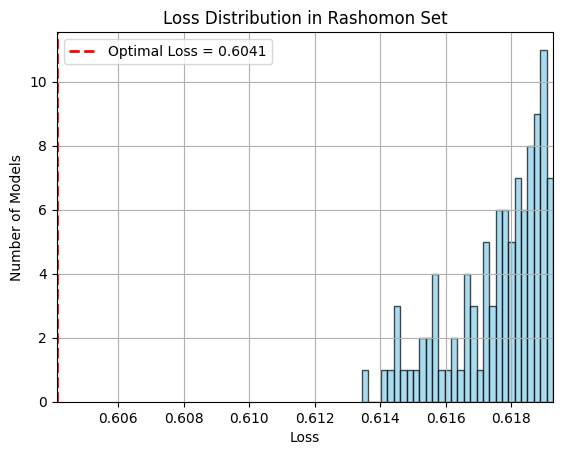

METHOD: uniform_surface_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.604133058254075


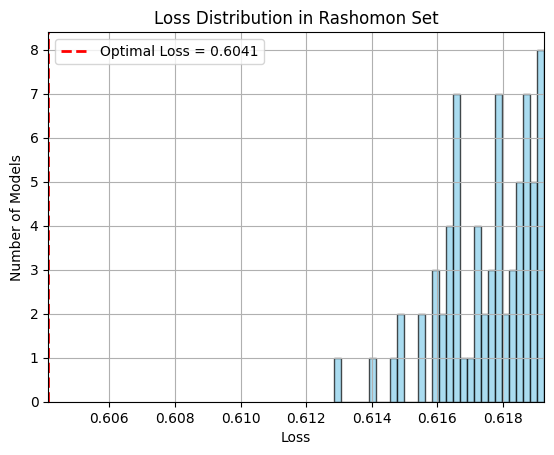

METHOD: poisson__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.604135054008898


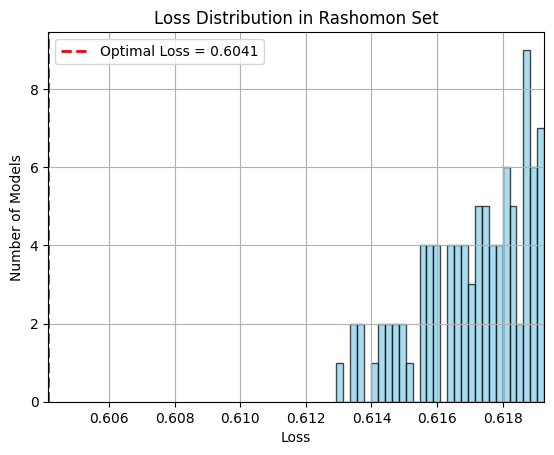

METHOD: poisson_euclidean_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041329259445345


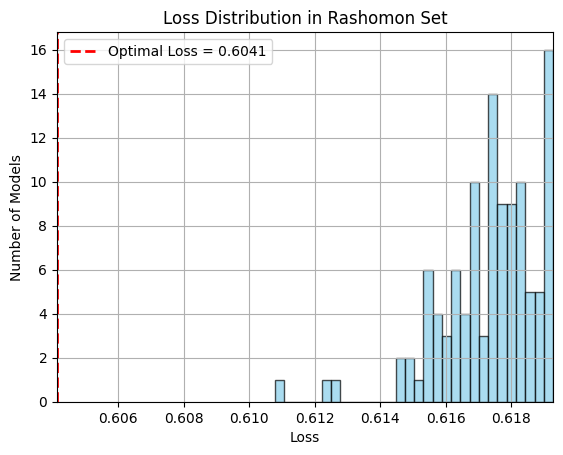

METHOD: permutation__ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041339265932434


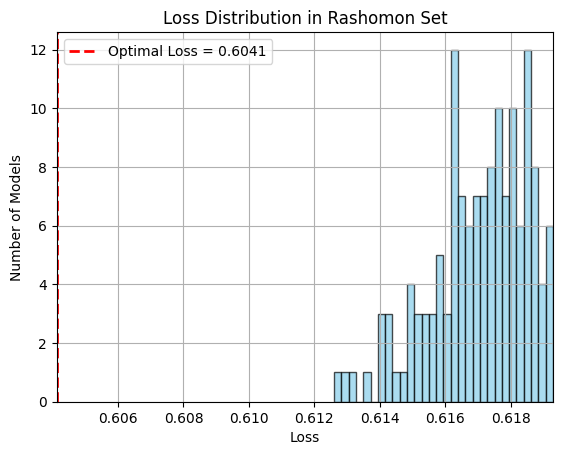

METHOD: permutation_poisson_ellipsoid_sampling
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041337073353824


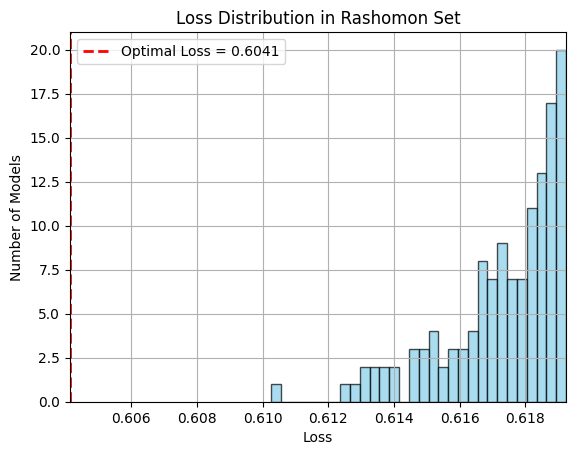

METHOD: blocking
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.6041333243225288


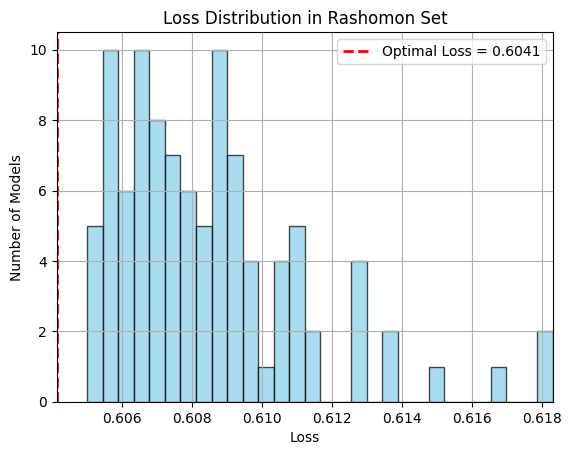

METHOD: quadratic
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.604134571258694


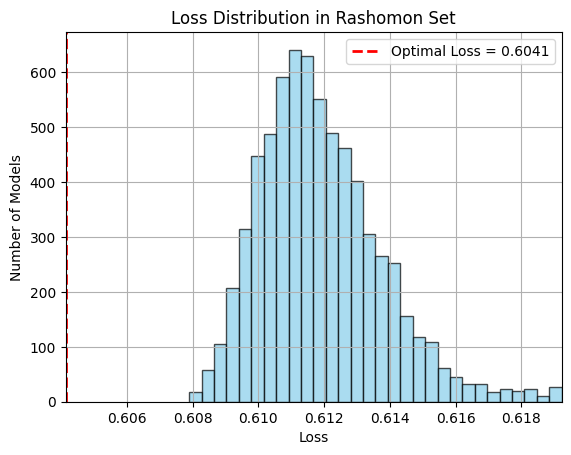

METHOD: swapping
optimal model
[ 0  1  2  3  4  5  6  7 12 13 14 15 16 17 18 19] 0.6023979724701976


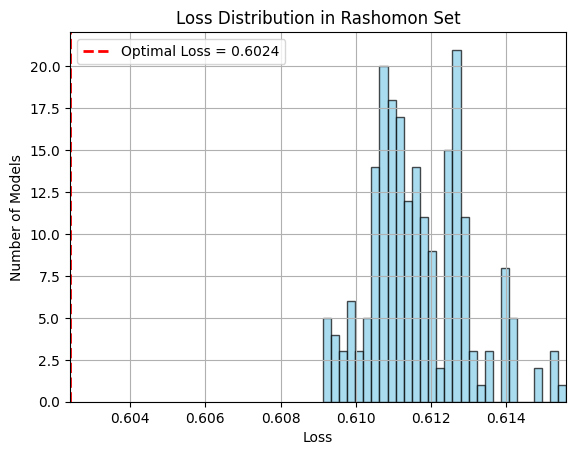

METHOD: hybrid
optimal model
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21] 0.5998436797638811


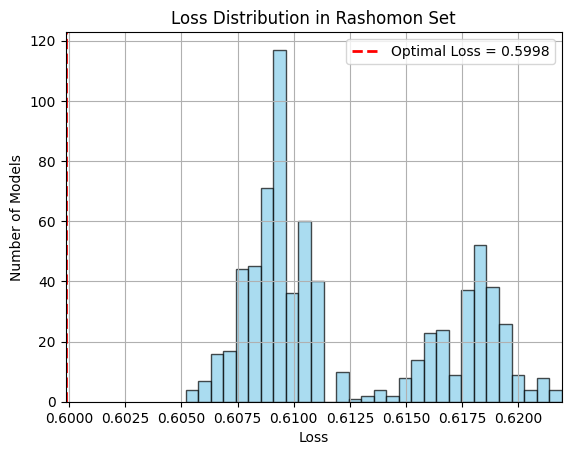

In [17]:
show_loss_distributions(all_datasets_results, "compas", "logistic")

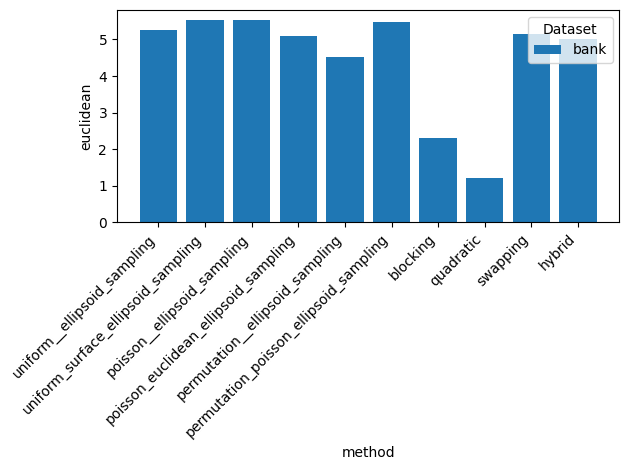

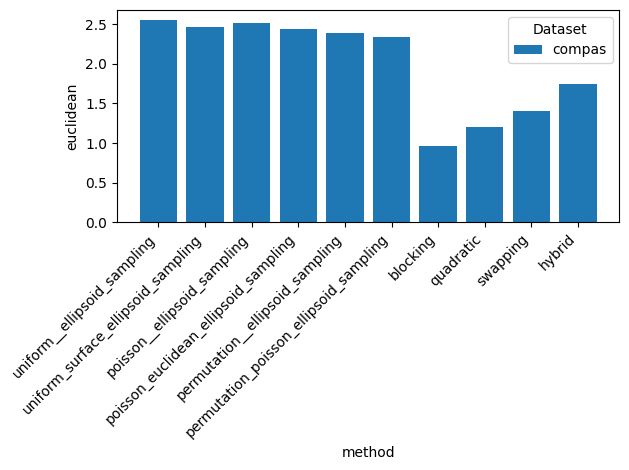

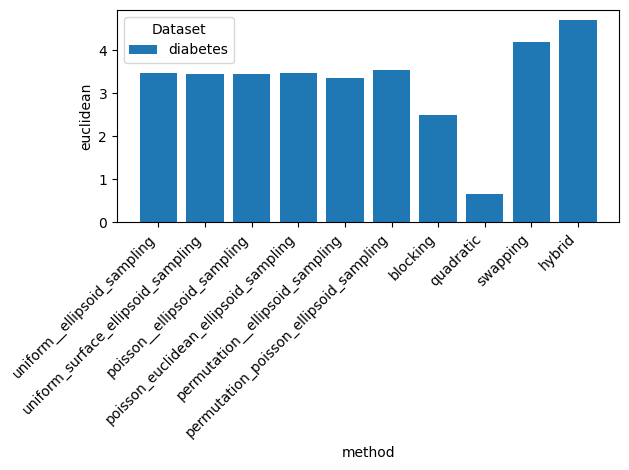

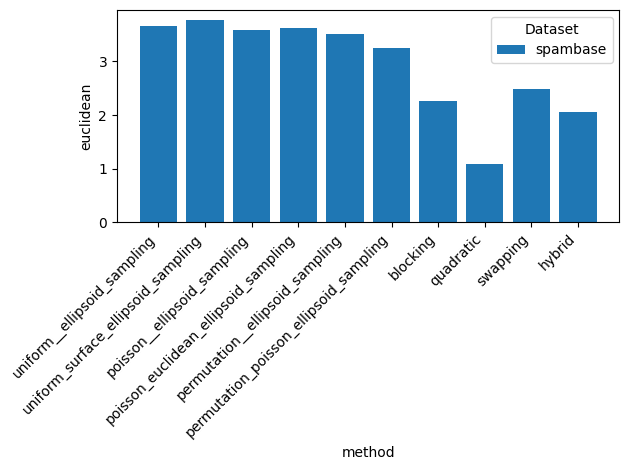

In [34]:
for dname in dataset_names[:-1]:
    show_bar_plot(all_datasets_results, dname, "euclidean")

method: uniform__ellipsoid_sampling


100%|██████████| 16/16 [00:00<00:00, 4548.21it/s]


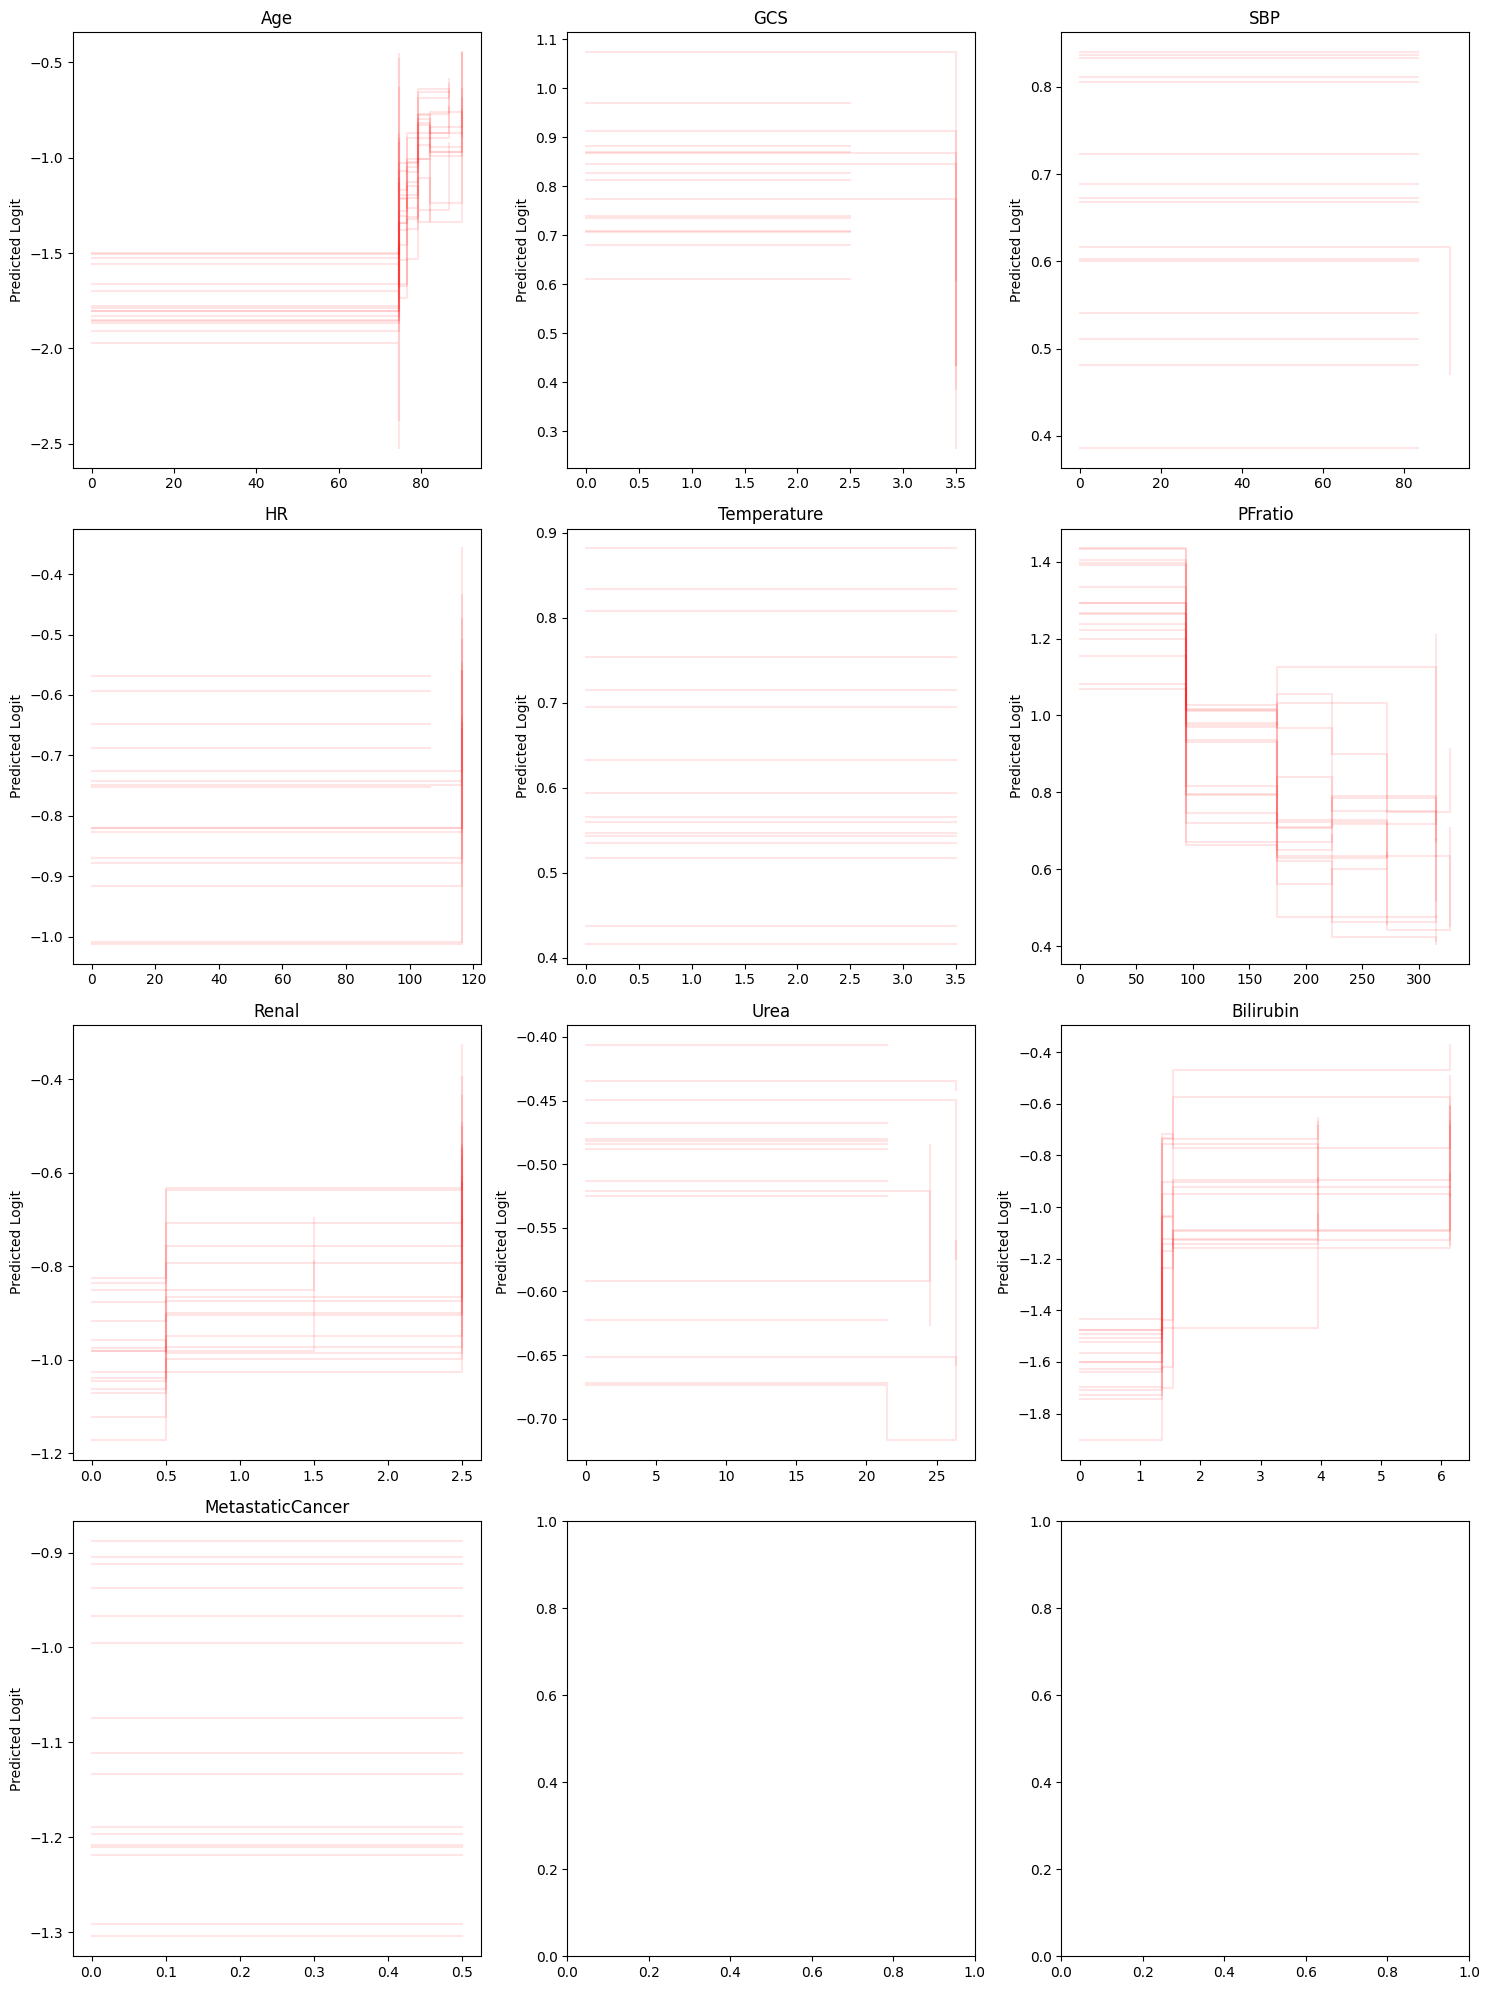

method: uniform_surface_ellipsoid_sampling


100%|██████████| 14/14 [00:00<00:00, 9143.61it/s]


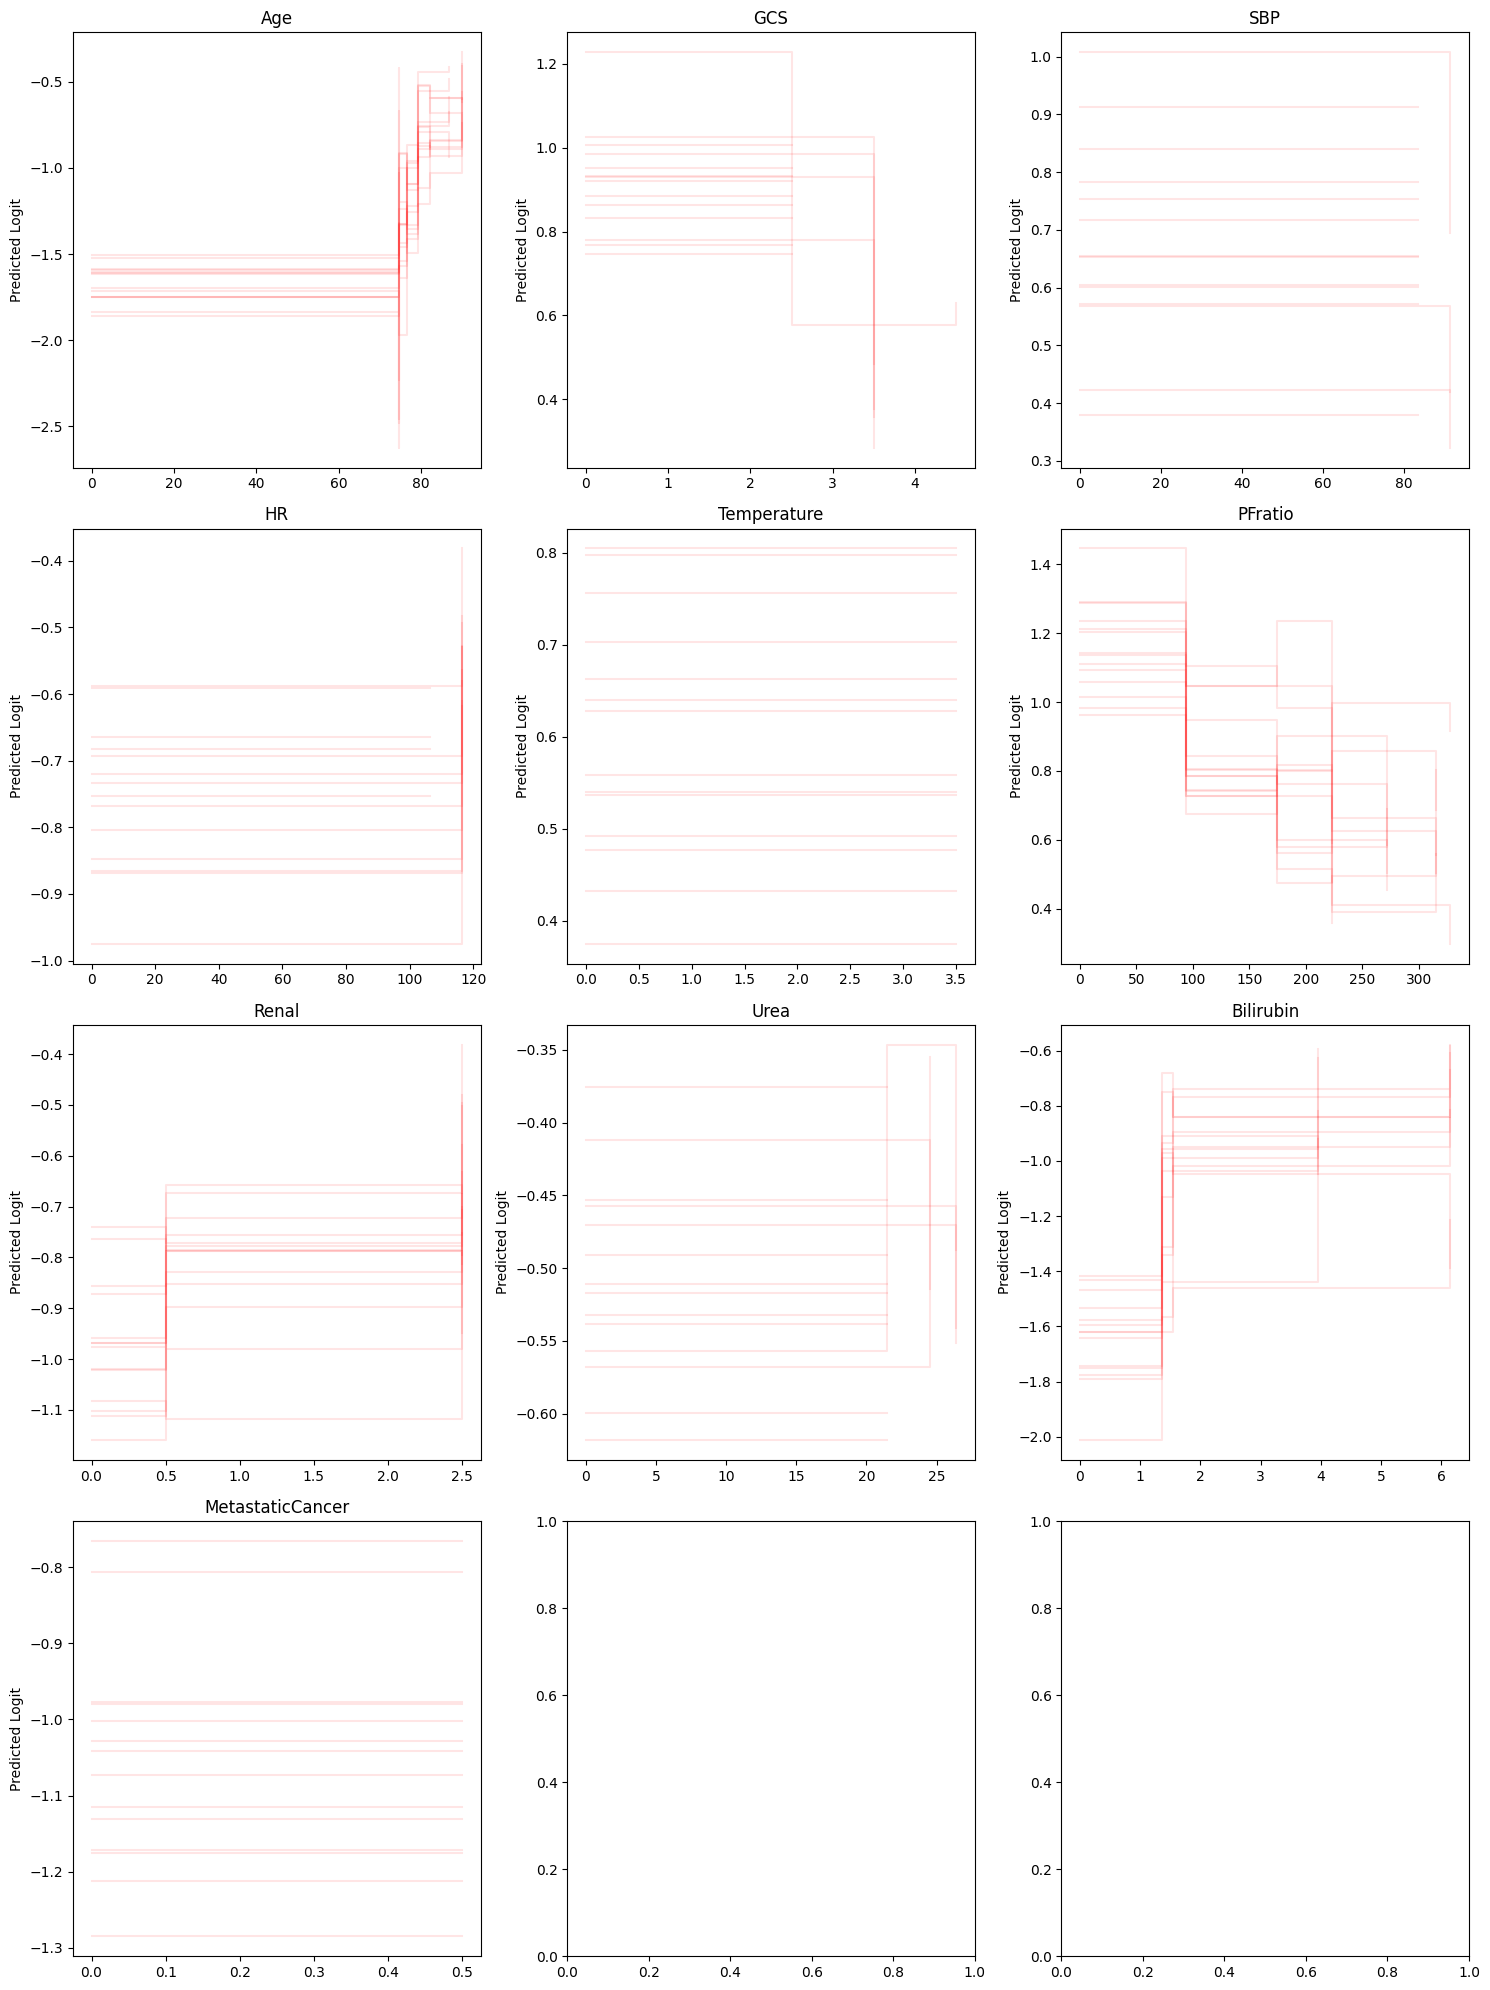

method: poisson__ellipsoid_sampling


100%|██████████| 6/6 [00:00<00:00, 10525.23it/s]


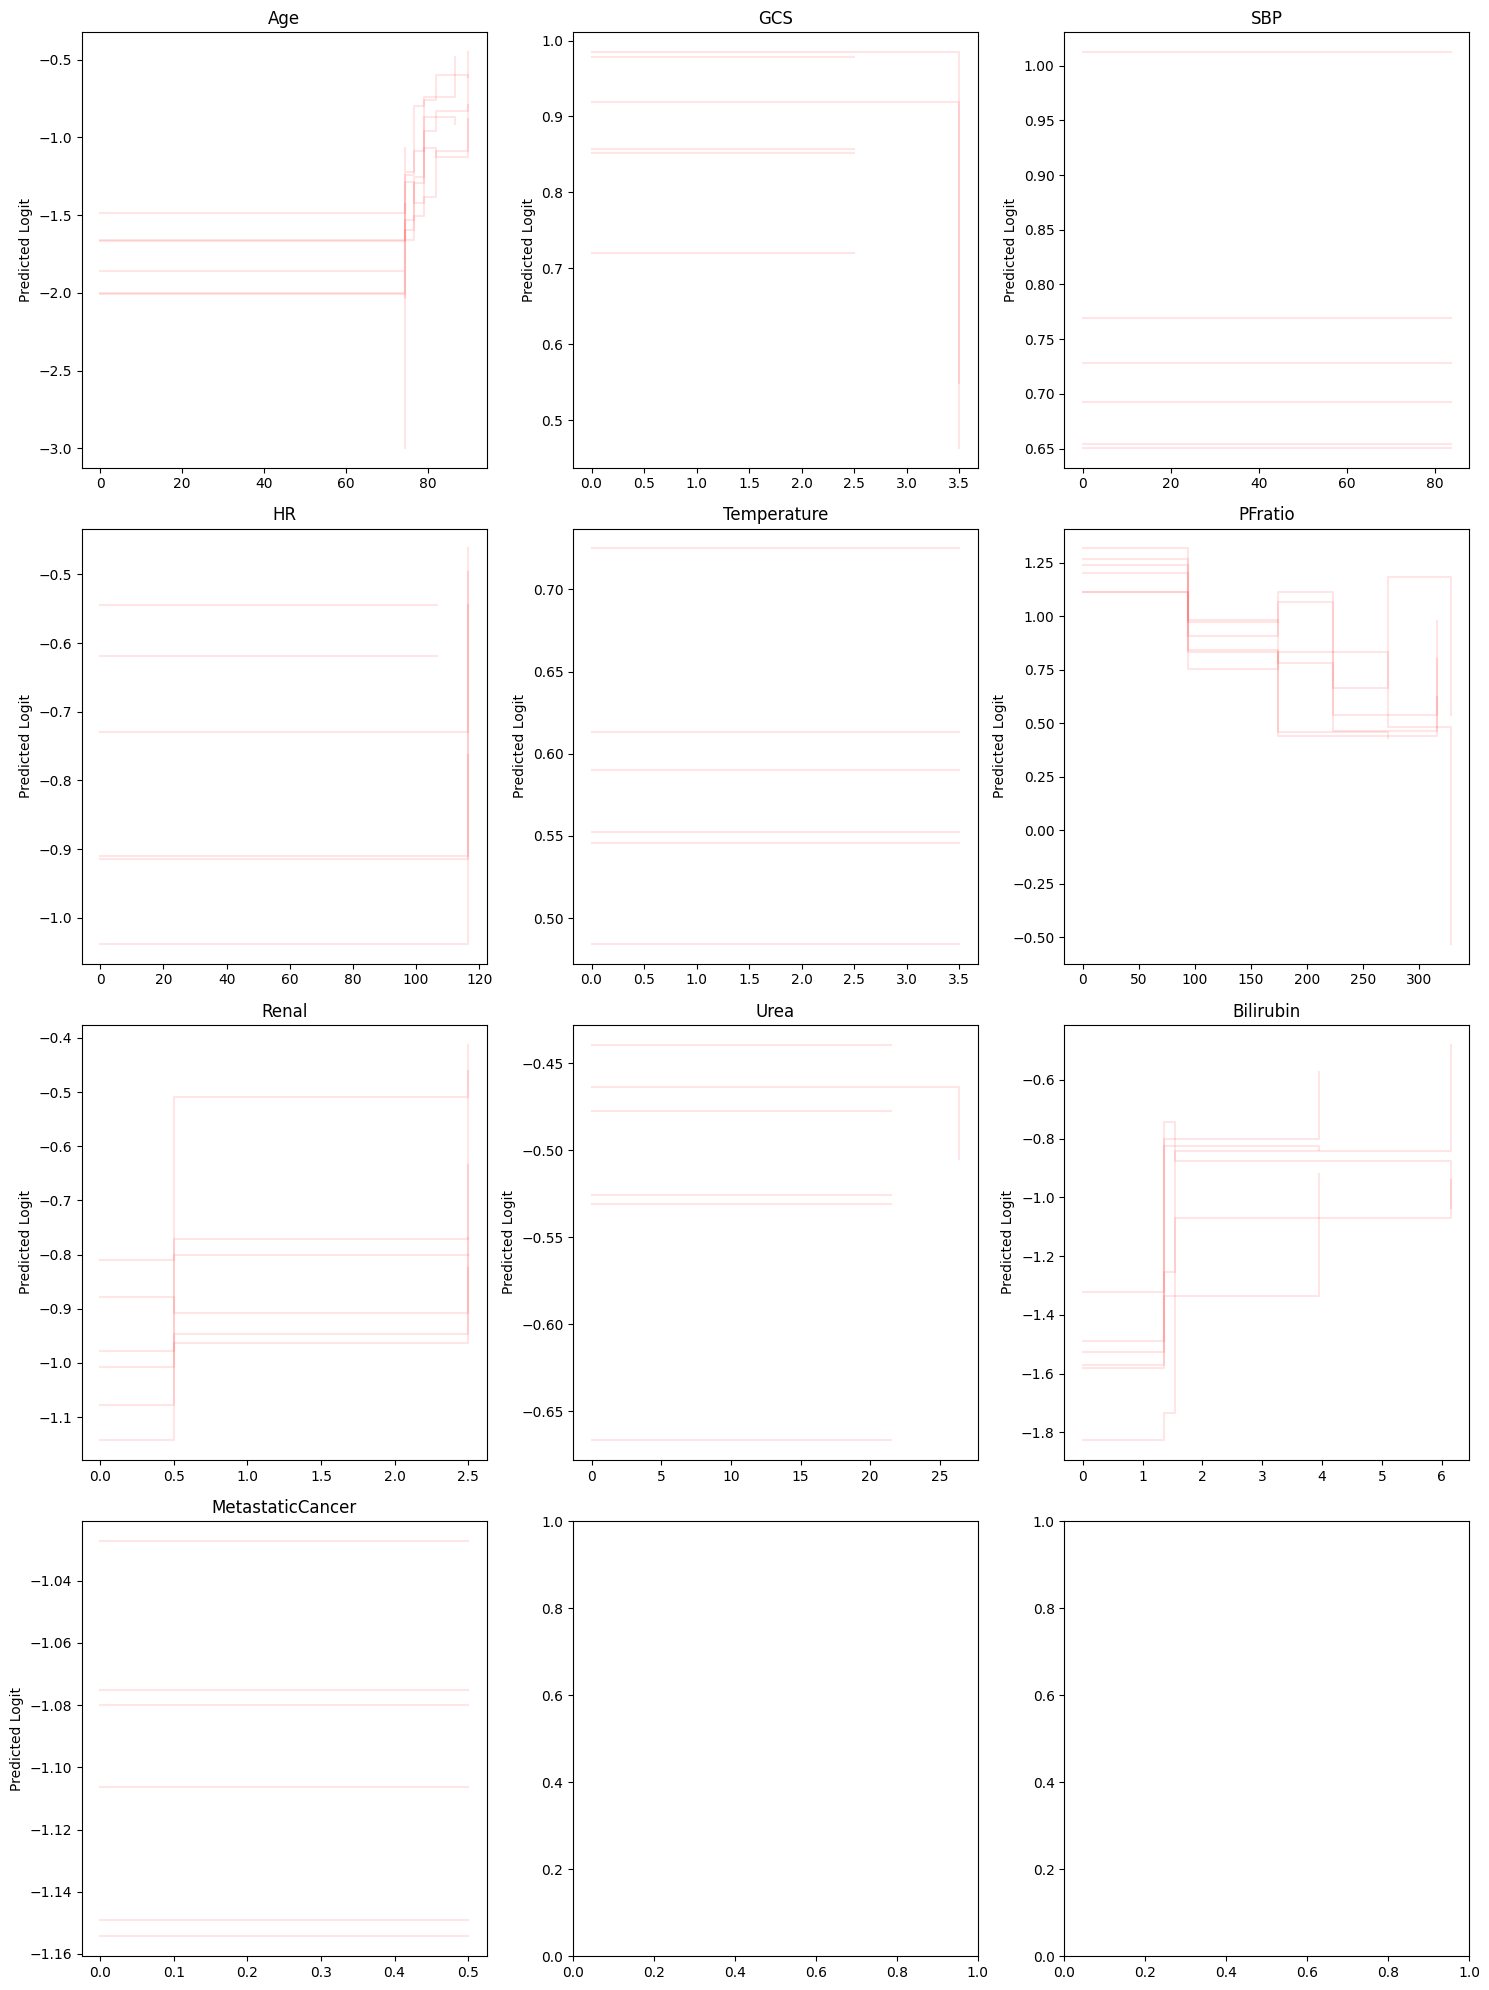

method: poisson_euclidean_ellipsoid_sampling


100%|██████████| 13/13 [00:00<00:00, 8713.00it/s]


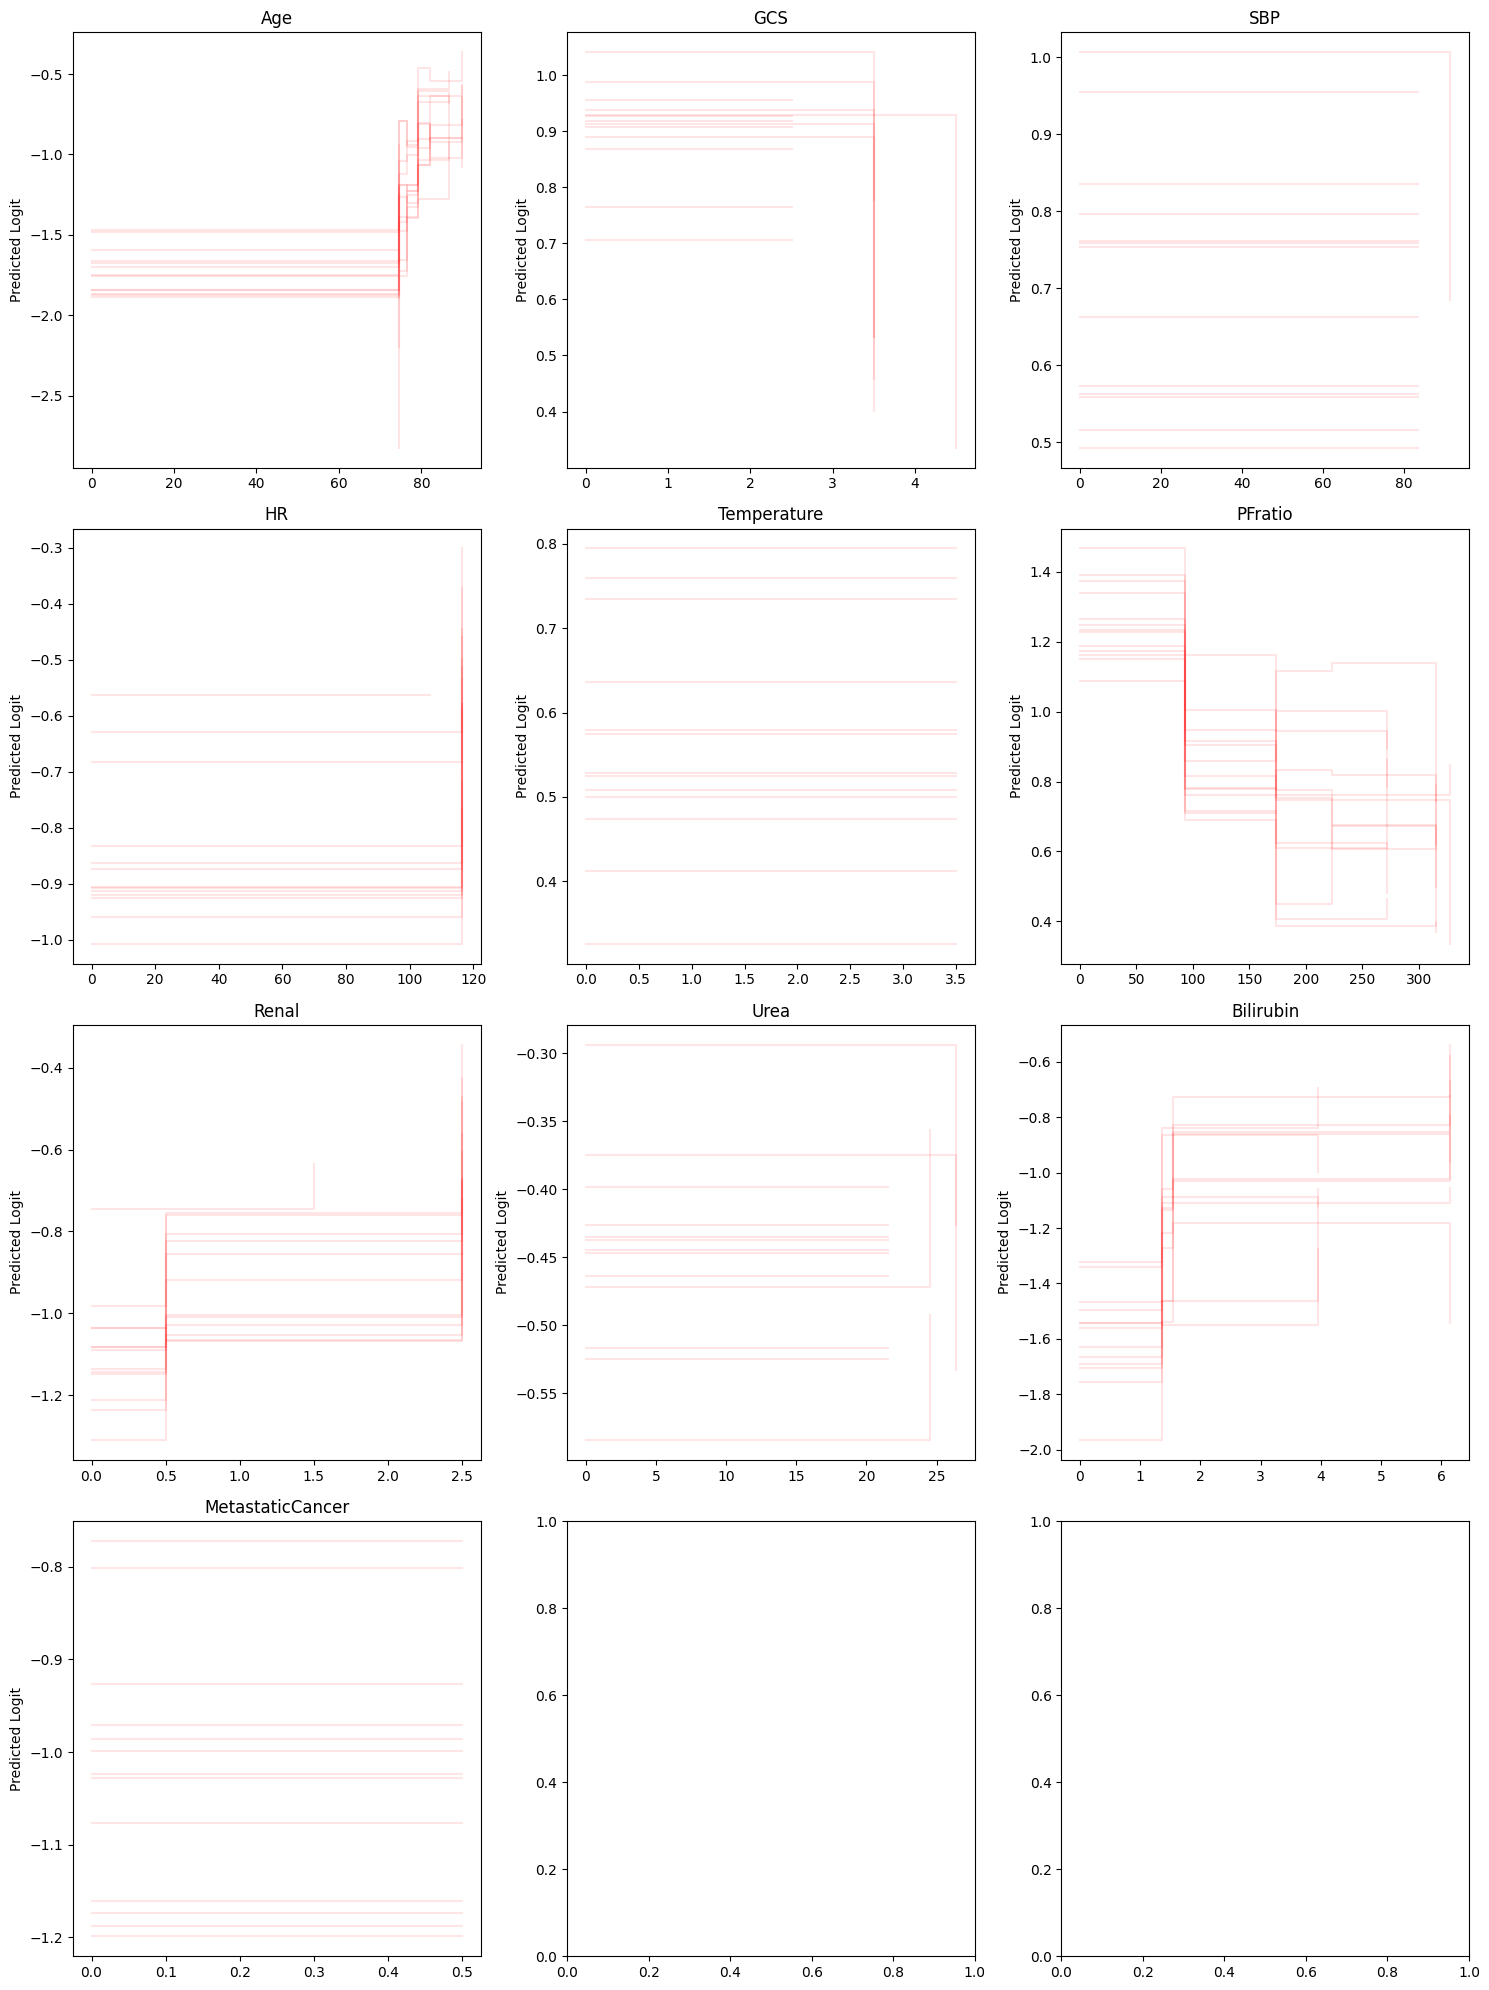

method: permutation__ellipsoid_sampling


100%|██████████| 20/20 [00:00<00:00, 8920.26it/s]


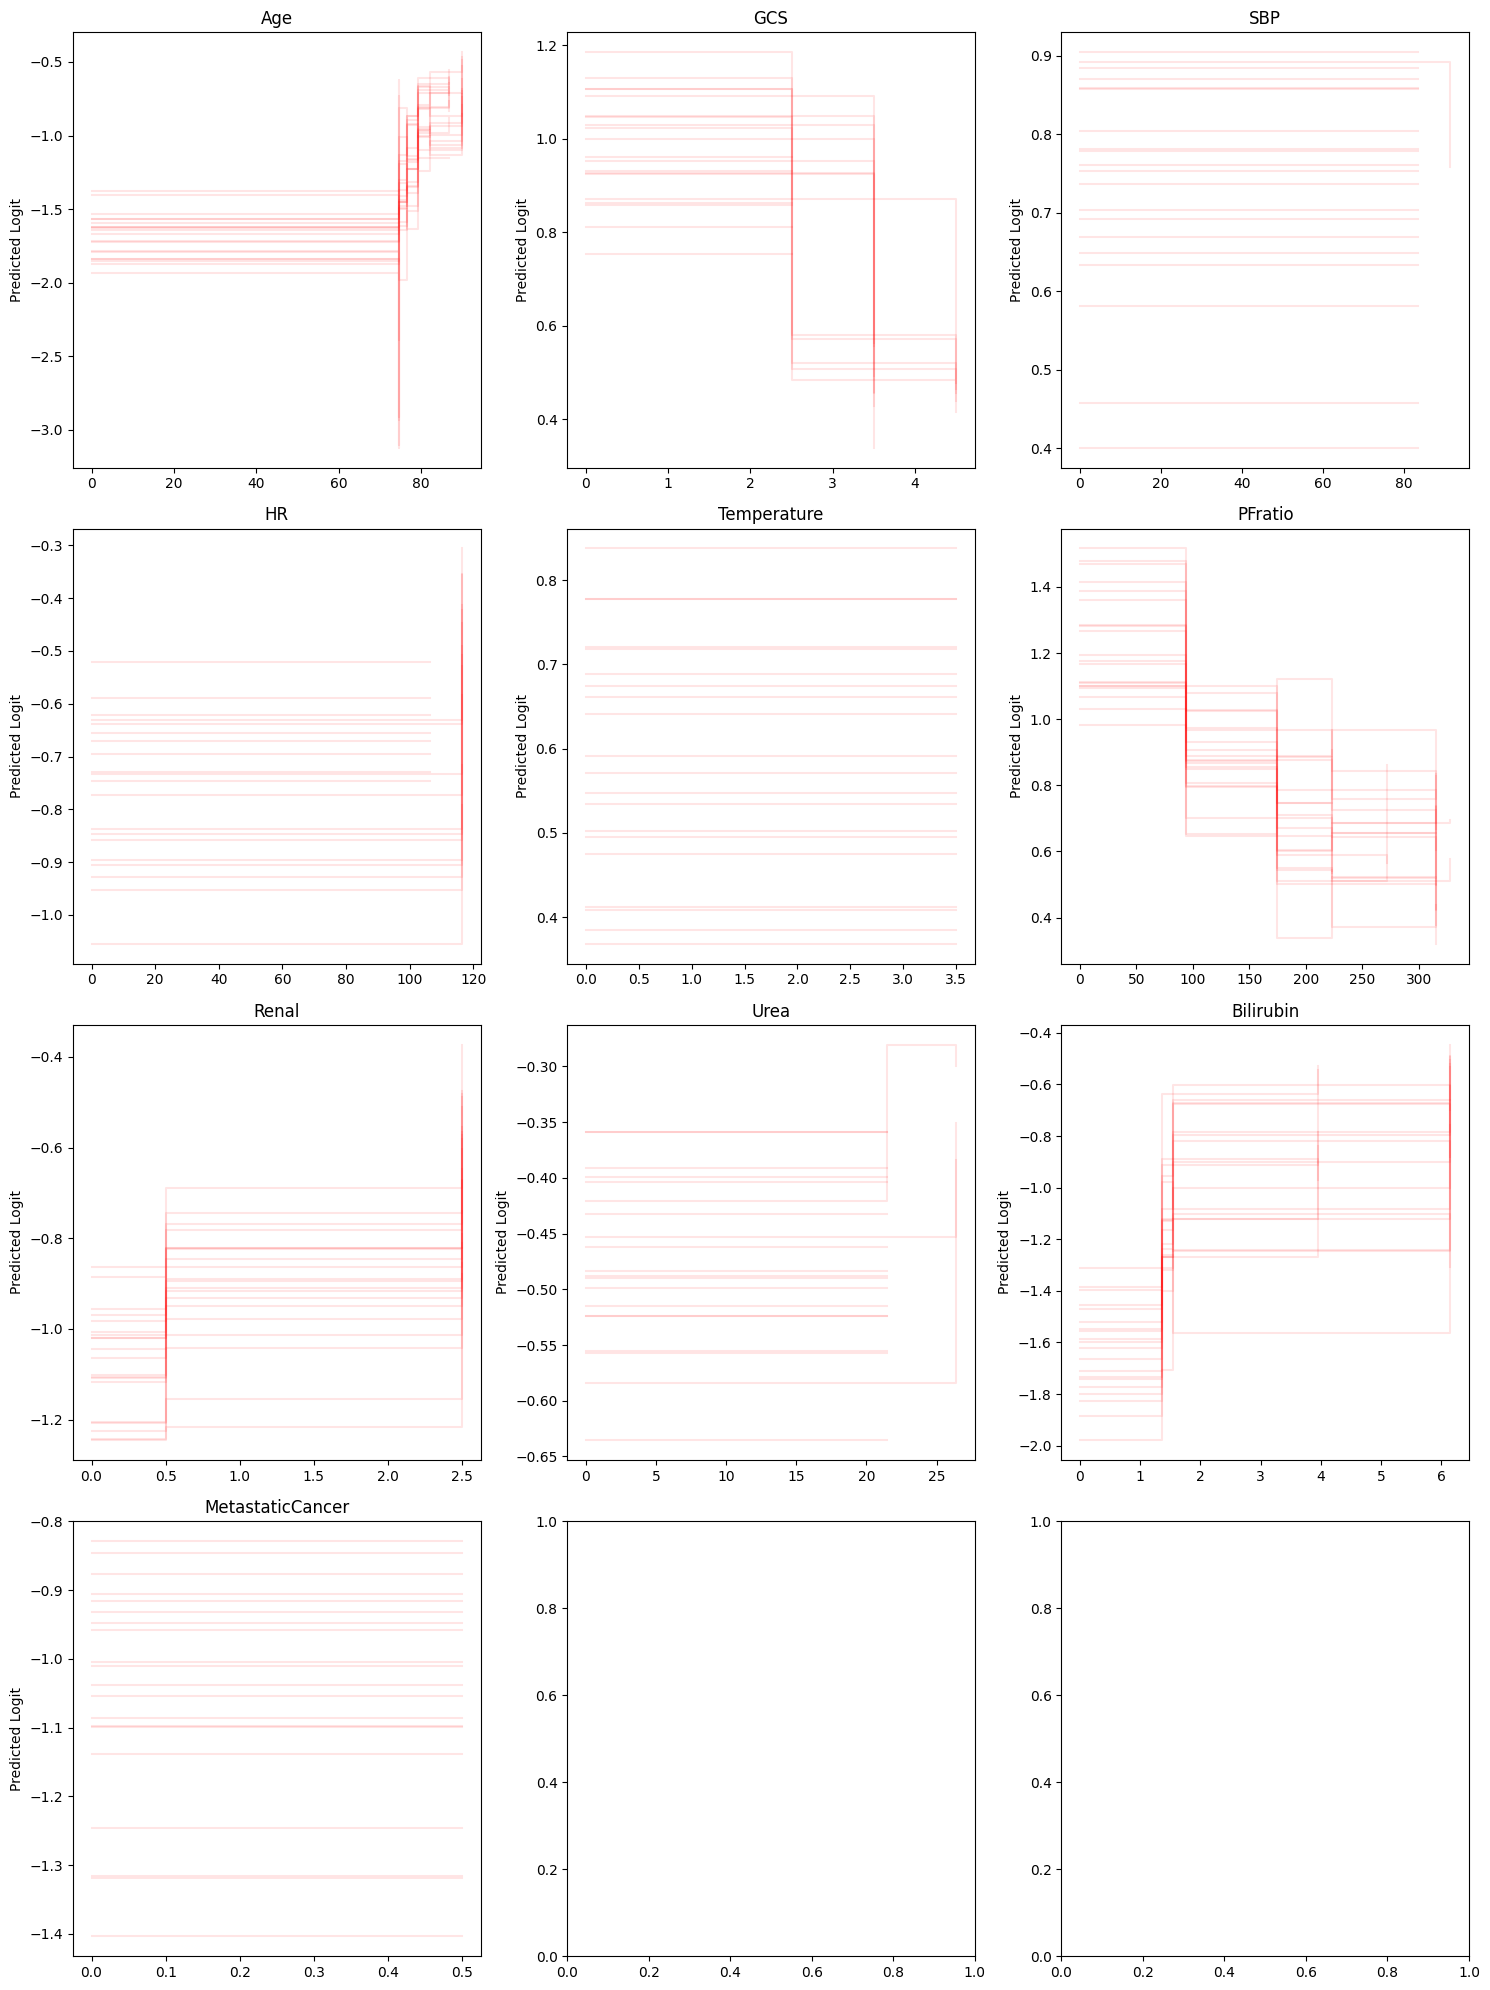

method: permutation_poisson_ellipsoid_sampling


100%|██████████| 8/8 [00:00<00:00, 9639.31it/s]


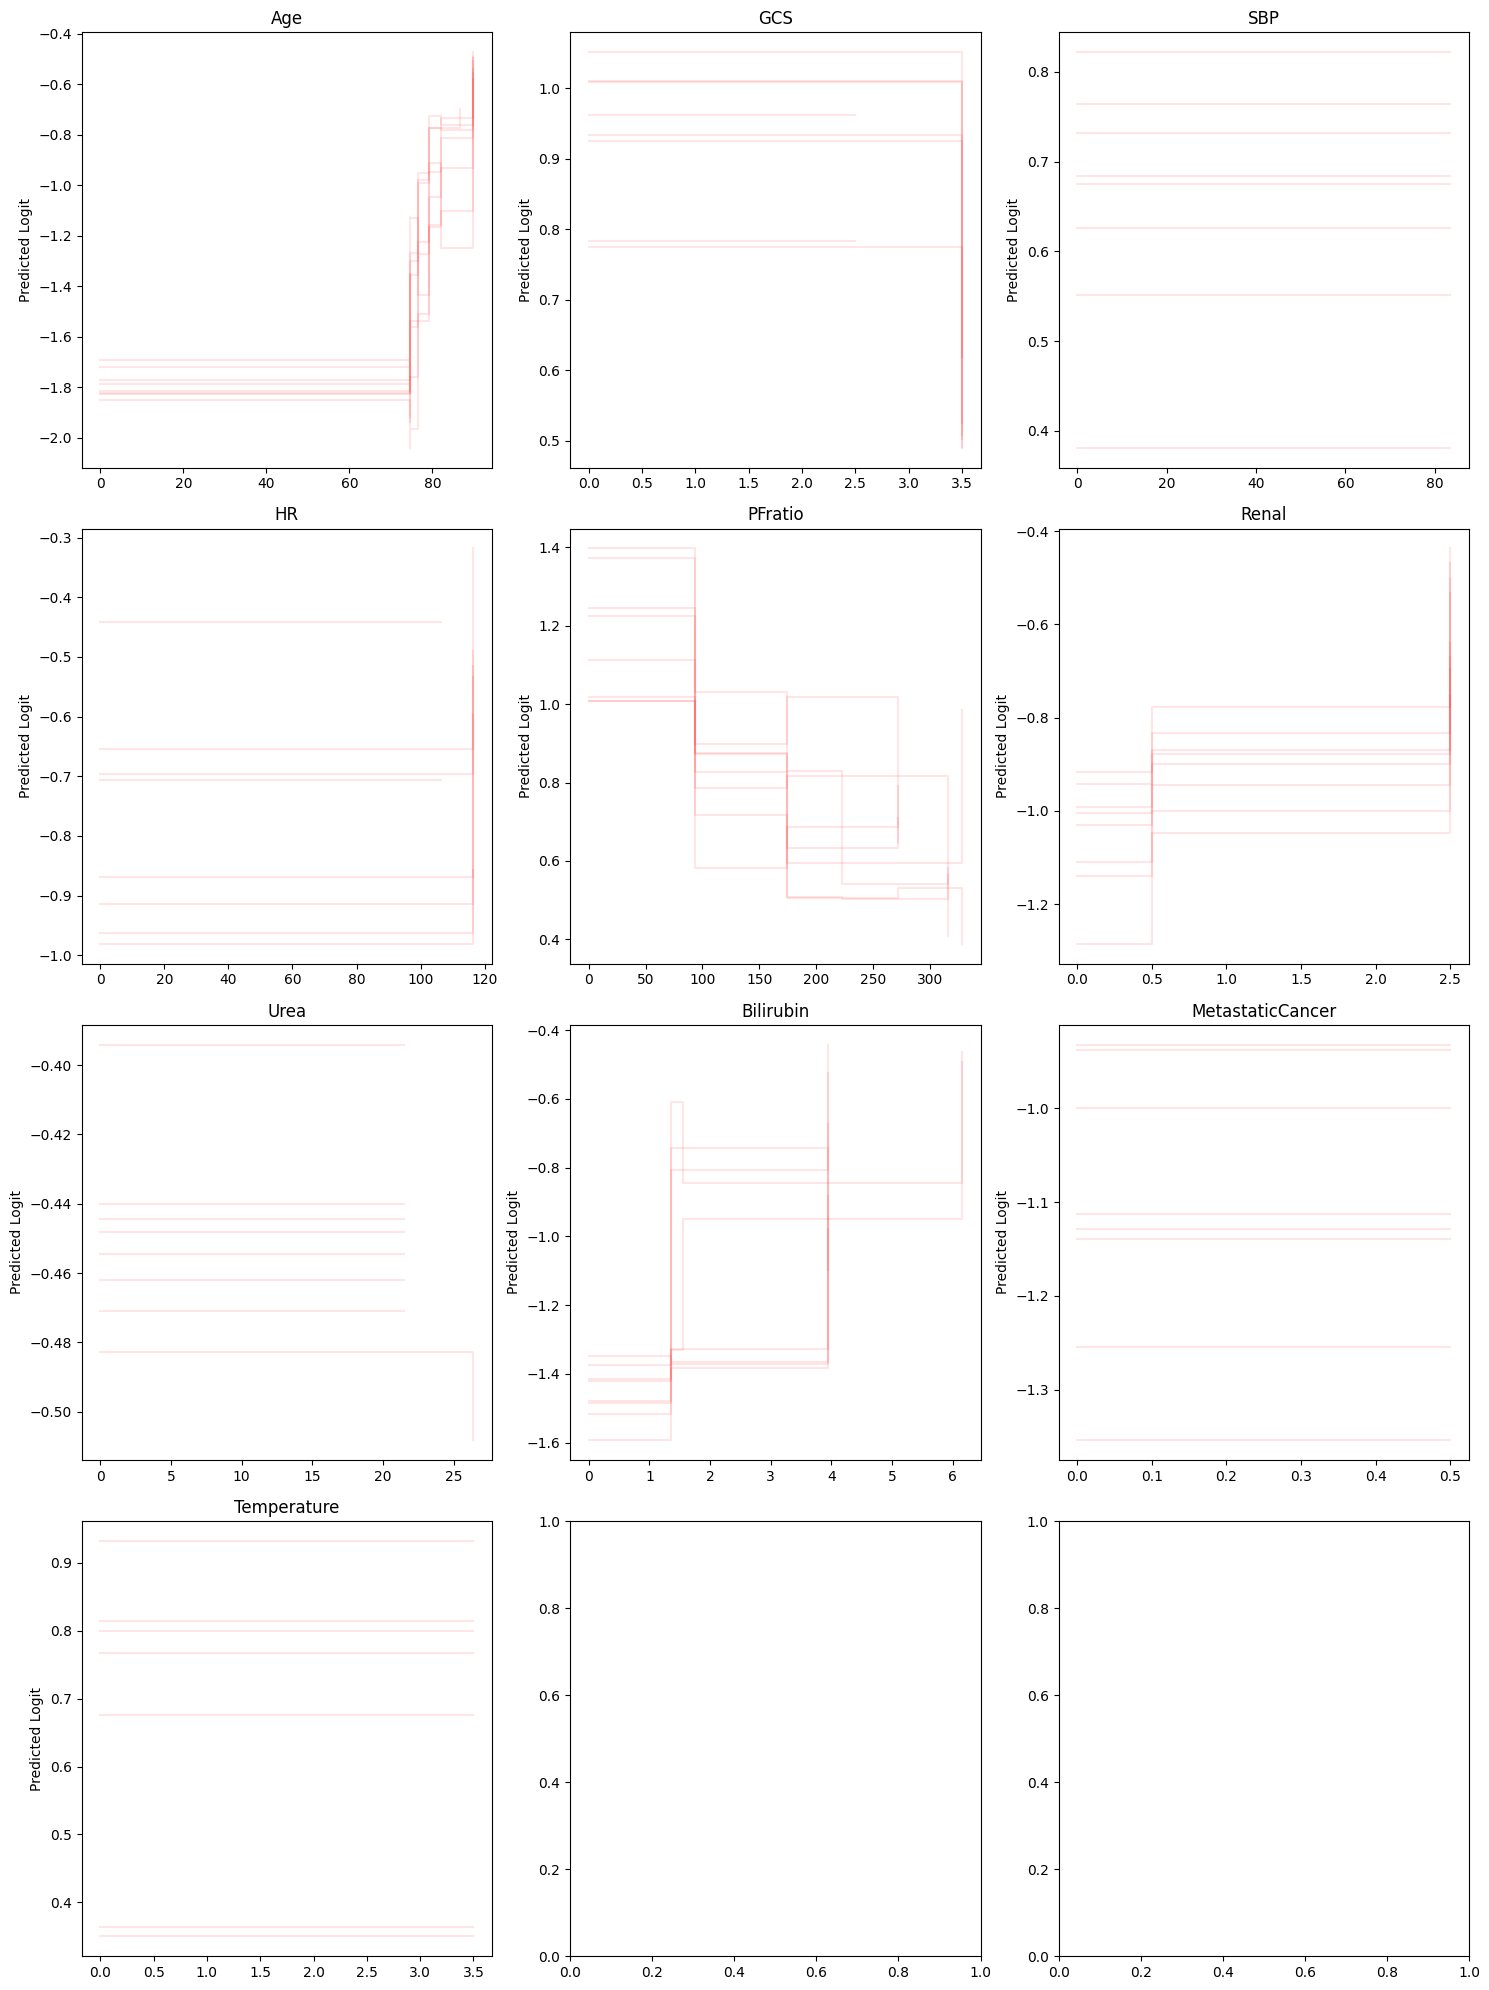

method: blocking


100%|██████████| 100/100 [00:00<00:00, 9862.68it/s]


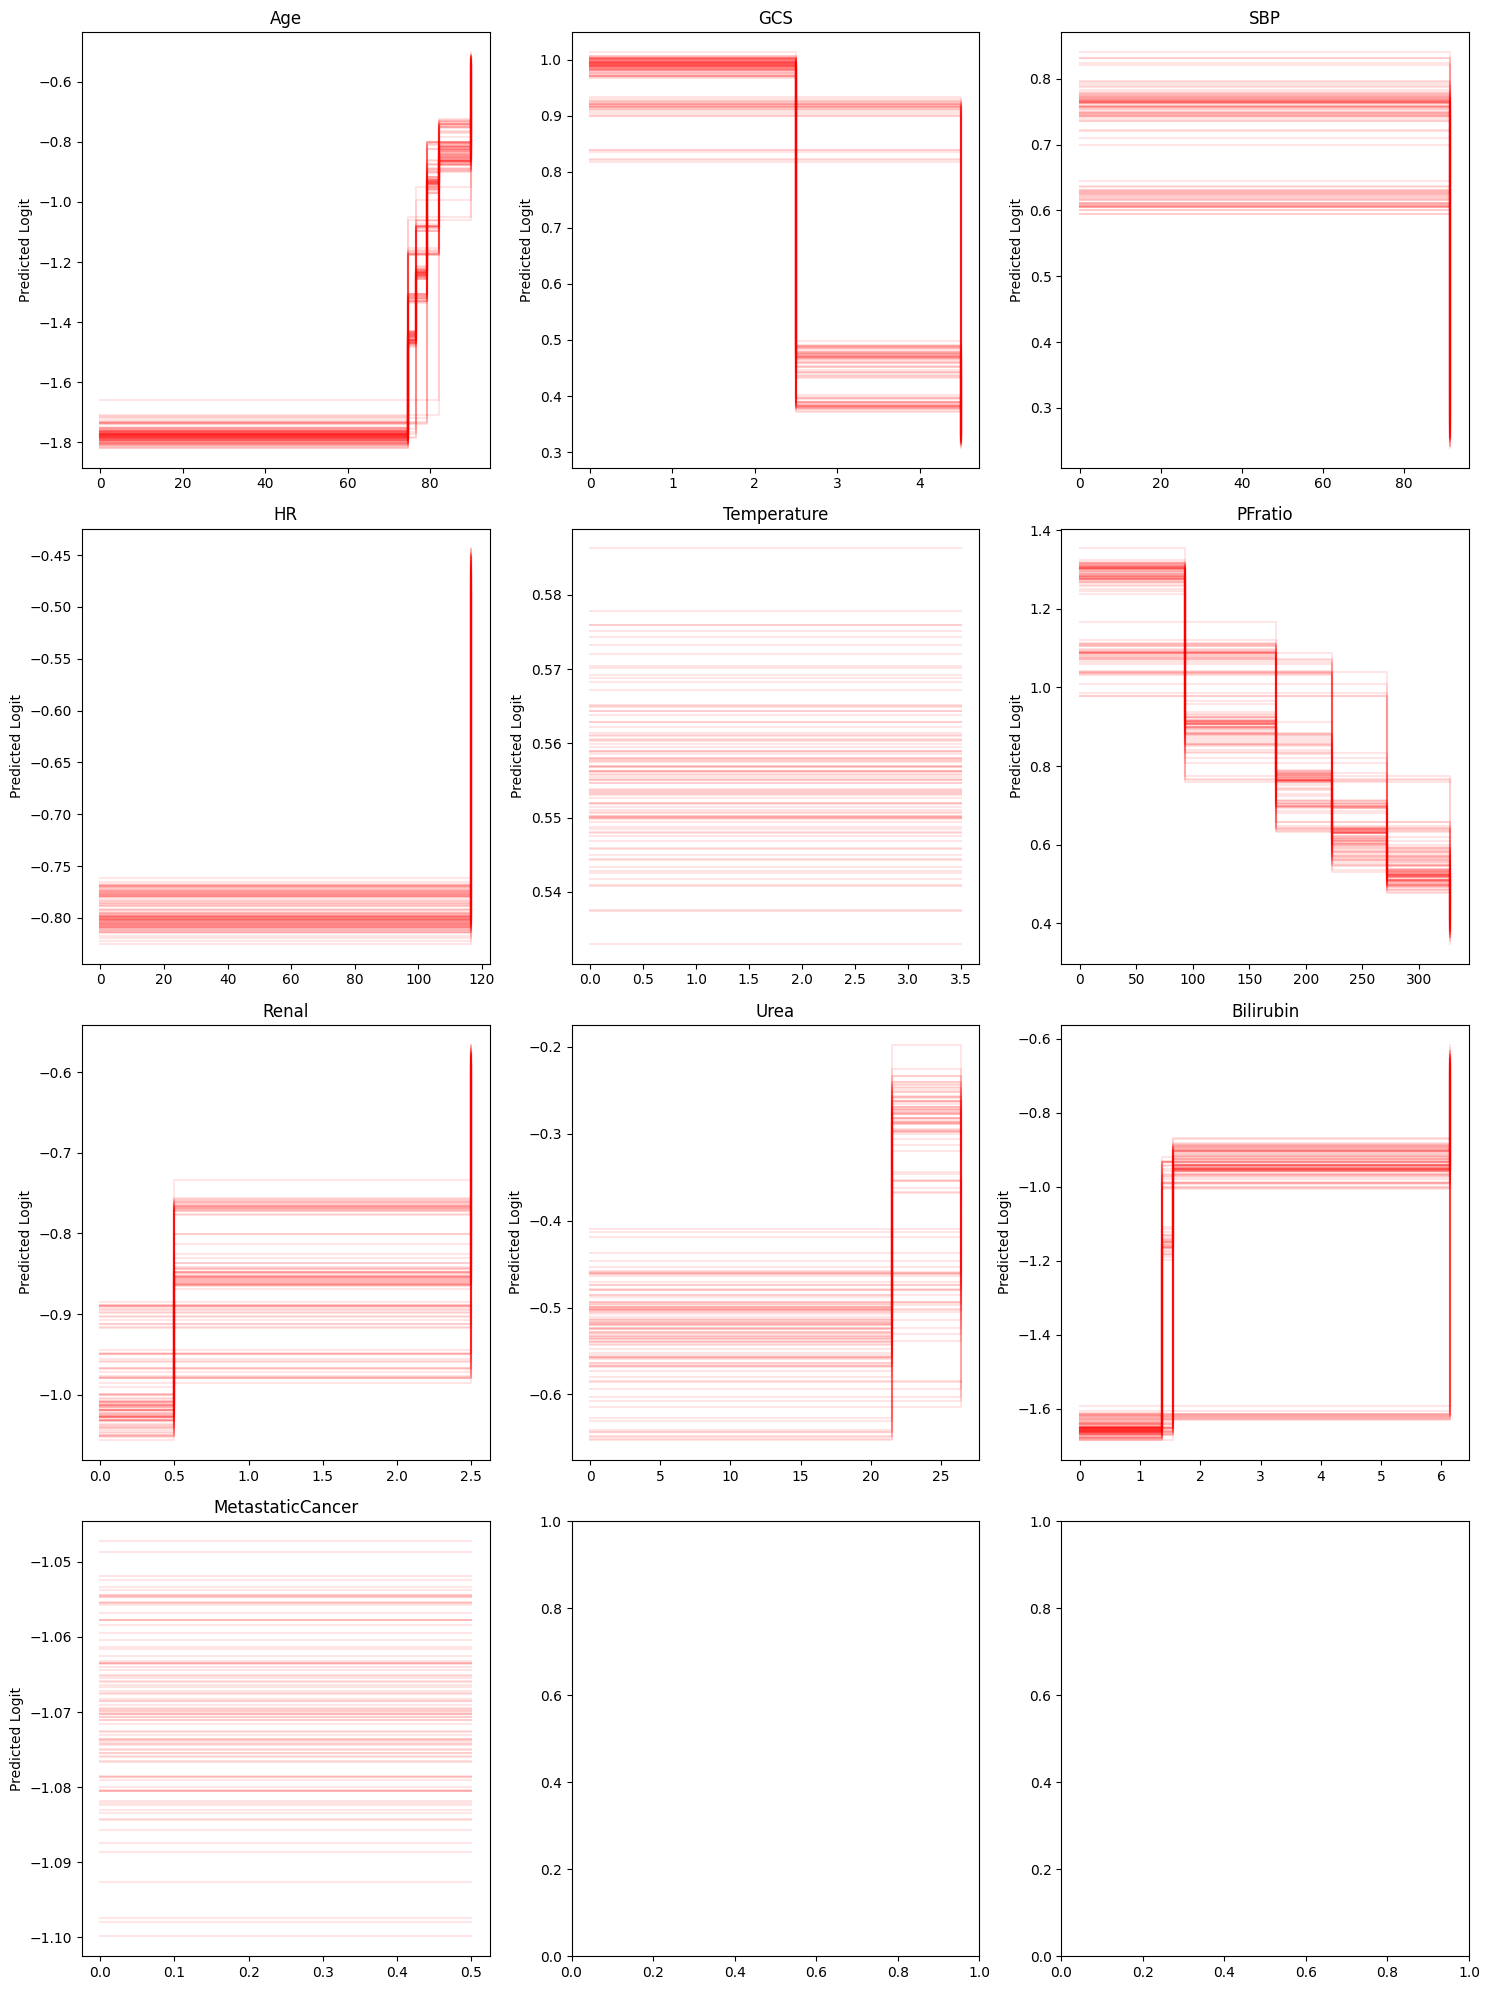

method: quadratic


100%|██████████| 1000/1000 [00:00<00:00, 11260.78it/s]


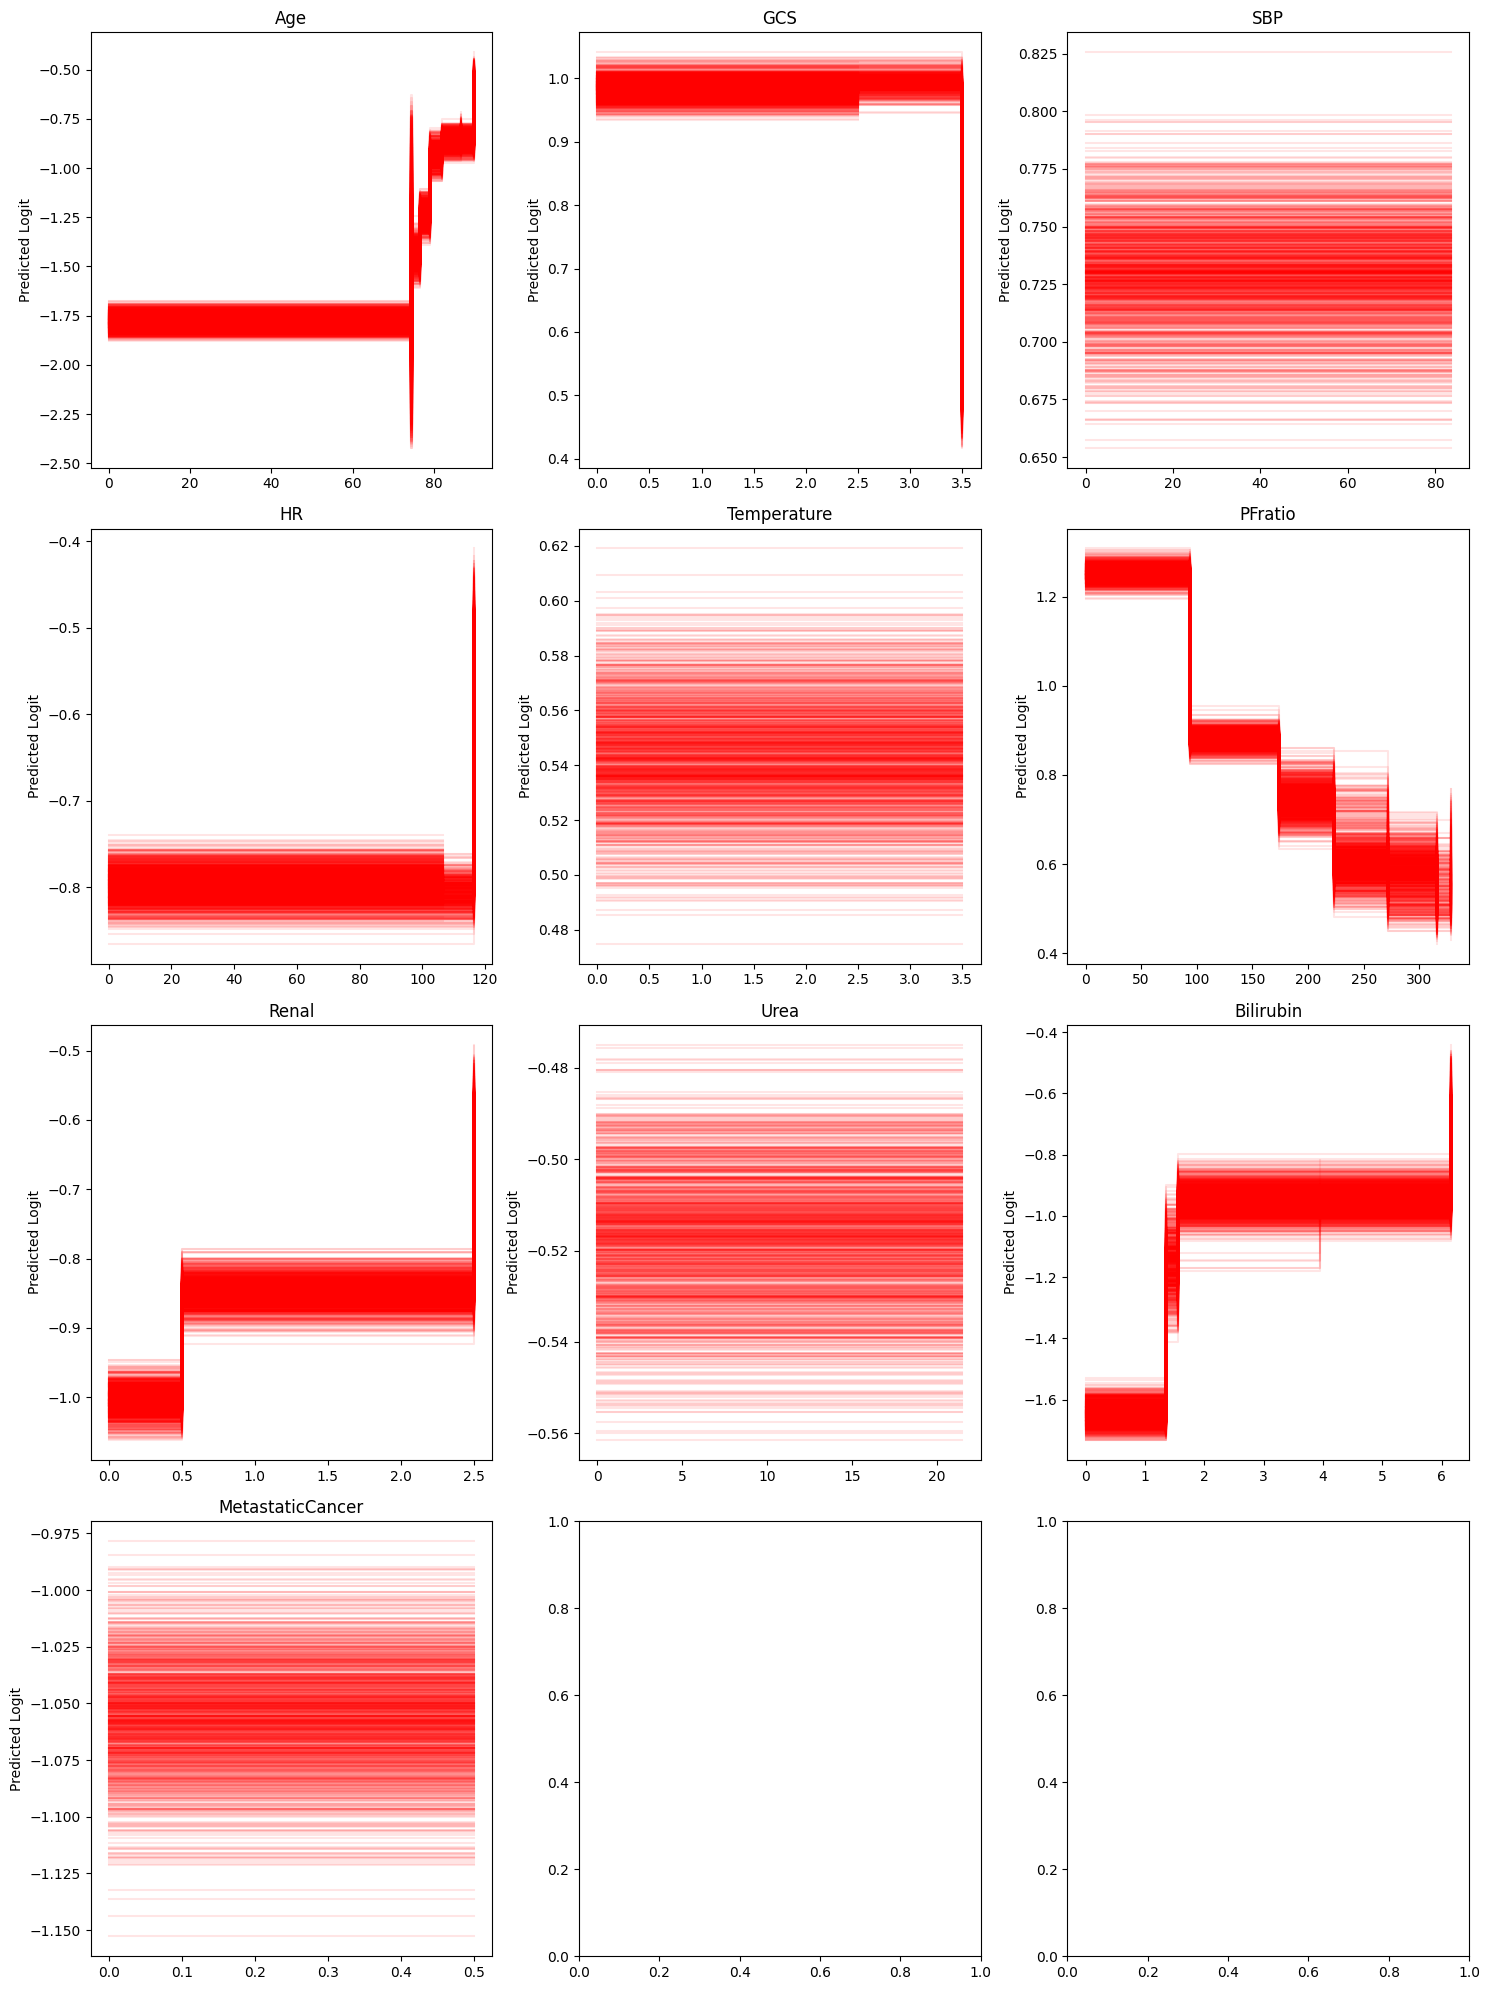

method: swapping


100%|██████████| 834/834 [00:00<00:00, 2550.98it/s]


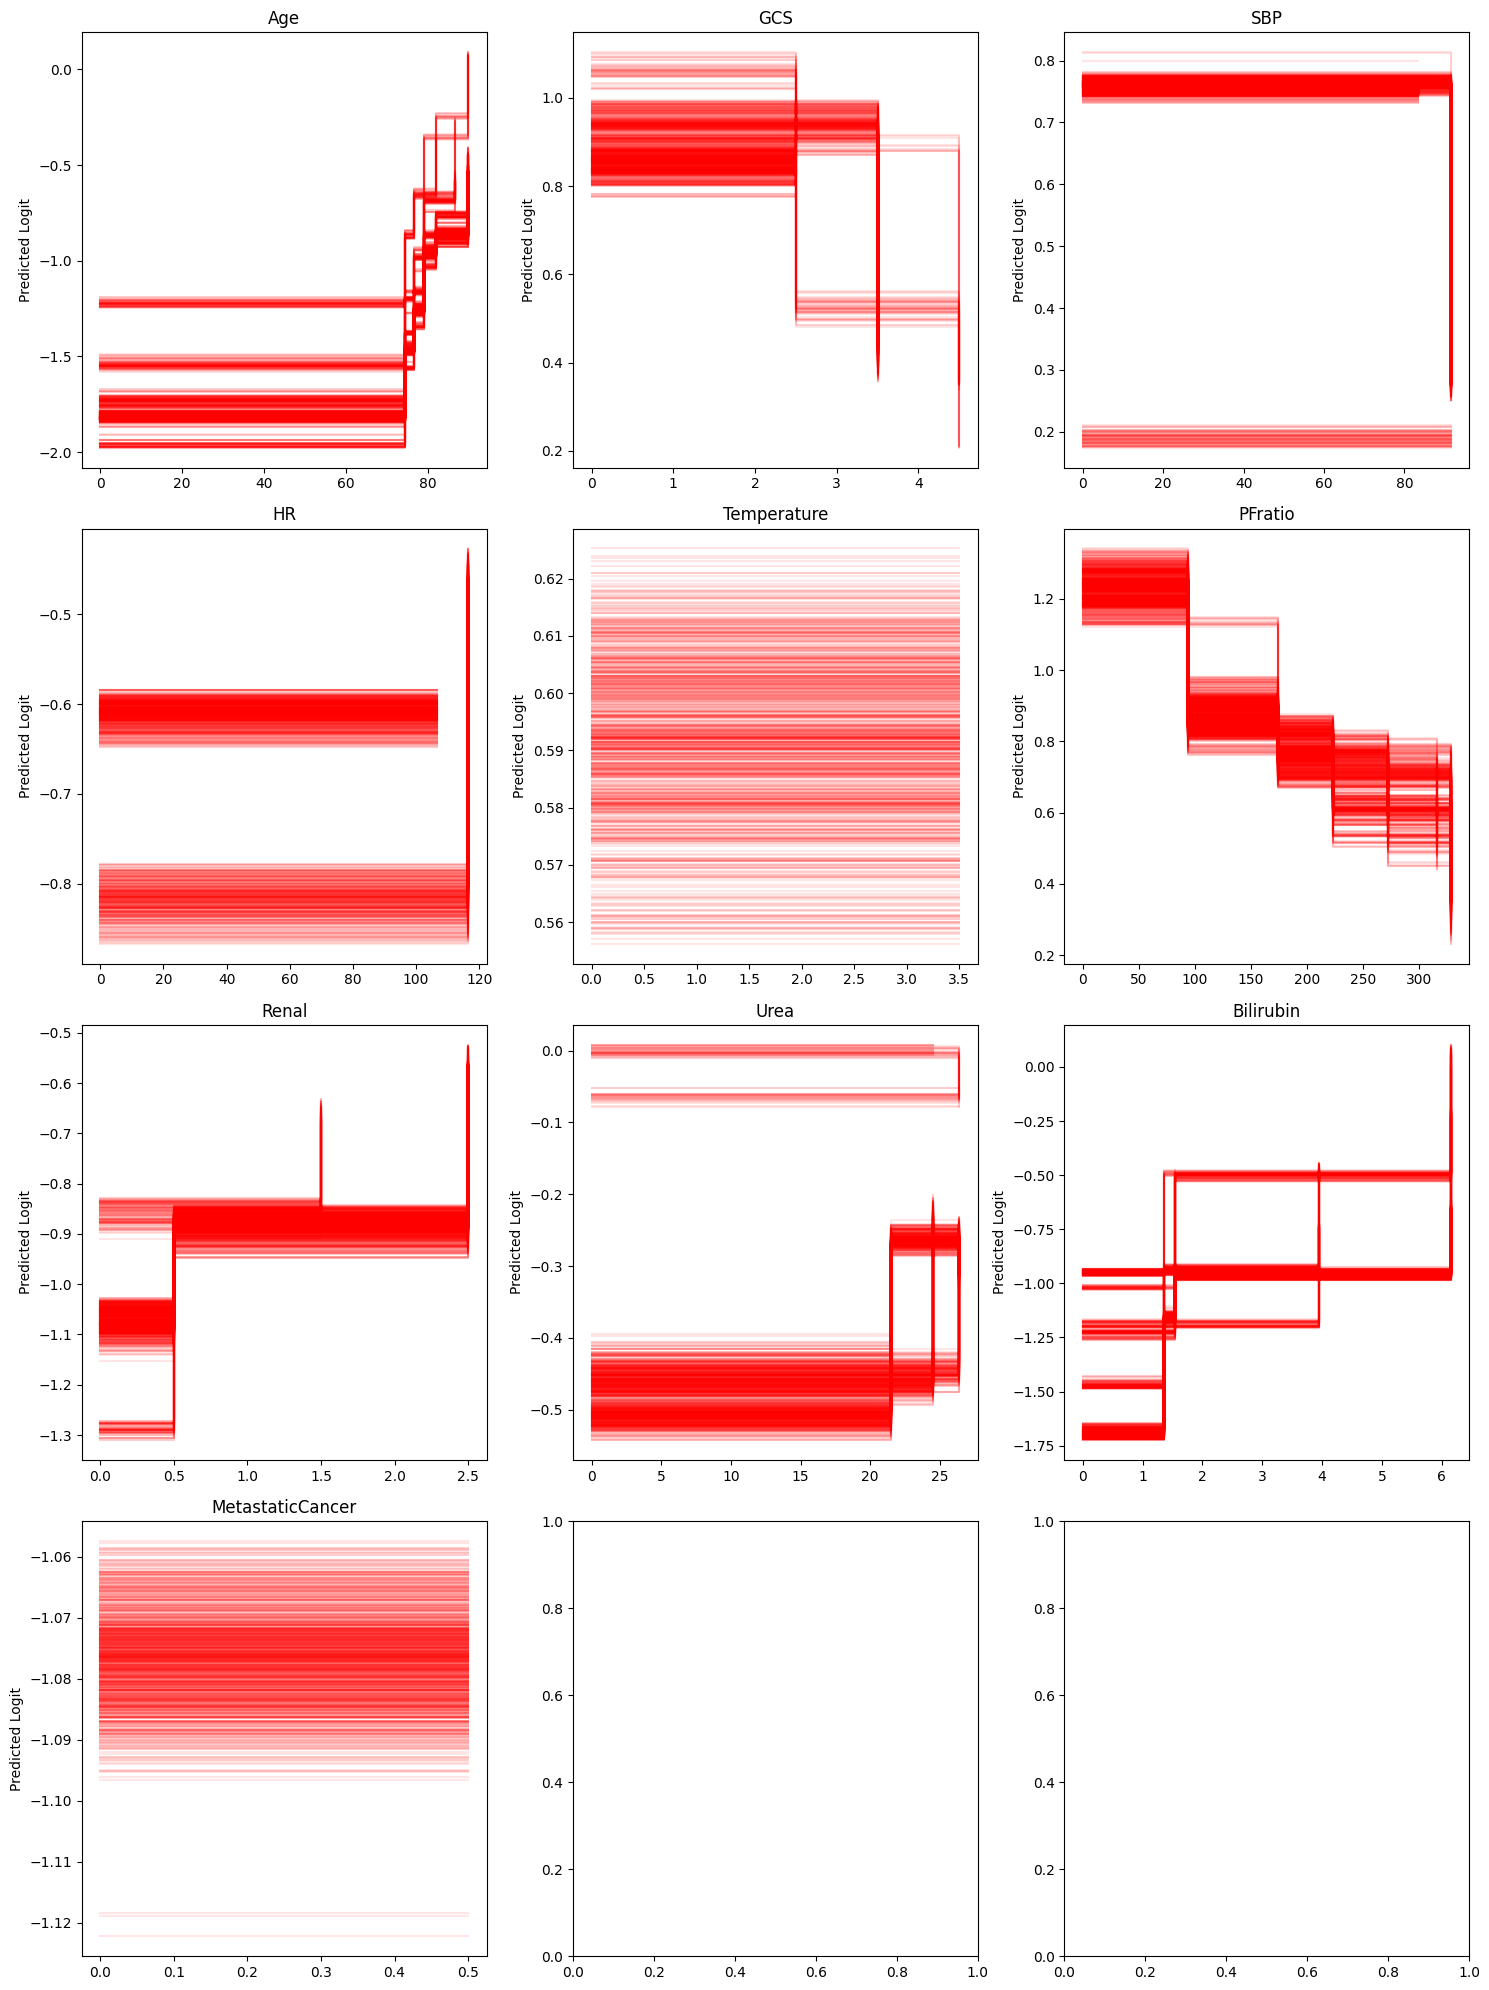

method: hybrid


100%|██████████| 1000/1000 [00:00<00:00, 11840.46it/s]


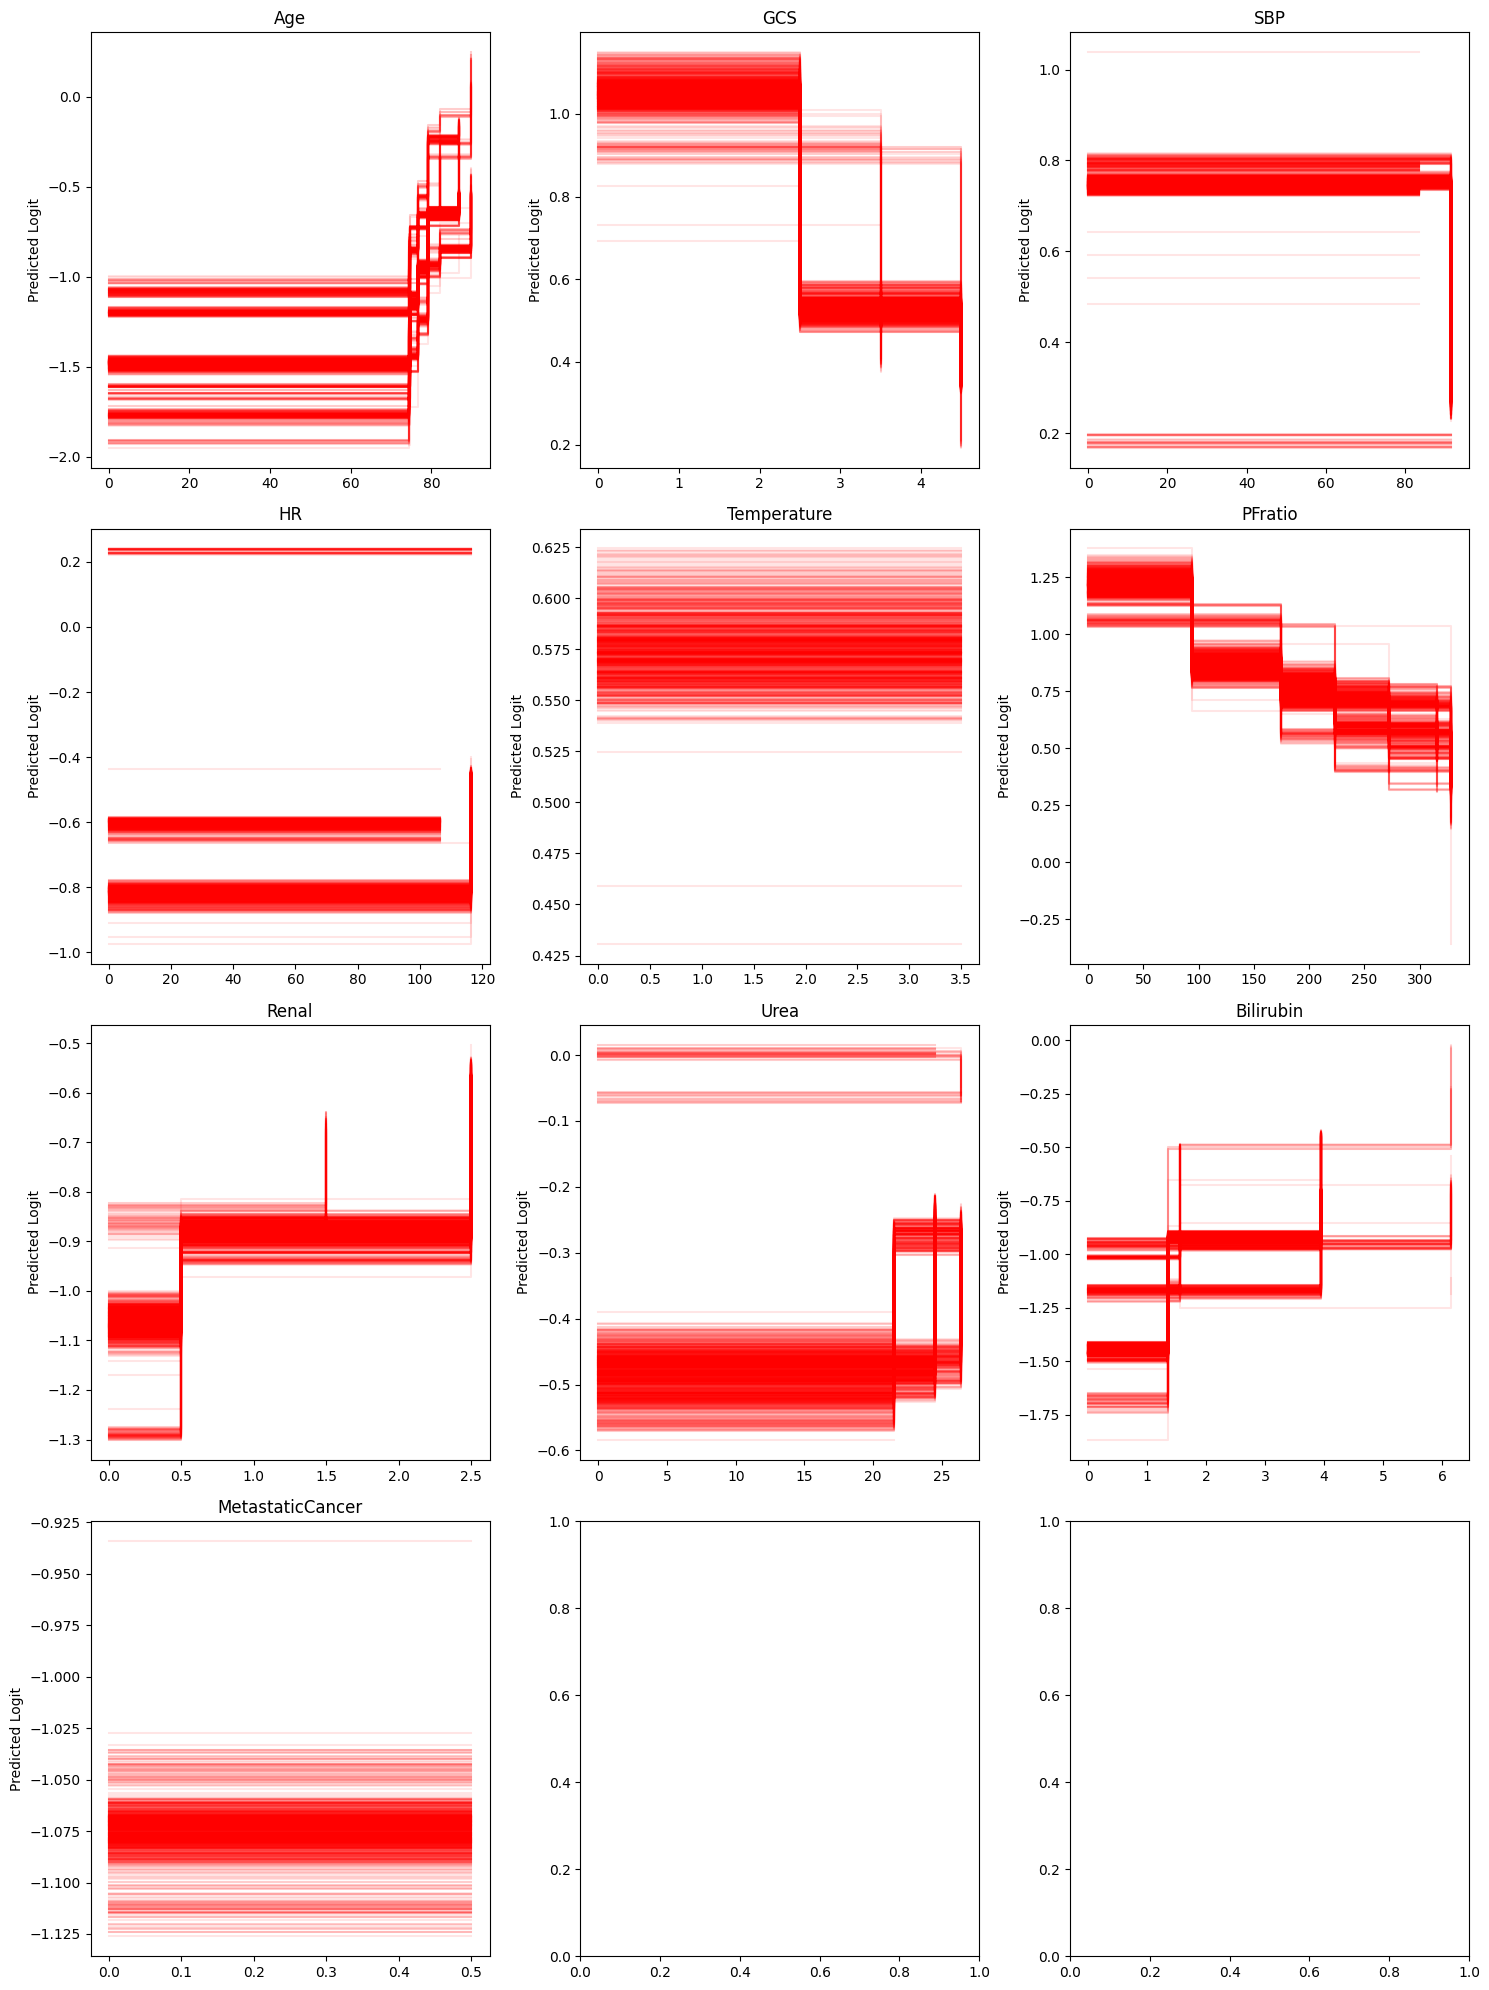

In [33]:
show_gam(all_datasets_results, 'mimic2')

method: uniform__ellipsoid_sampling, model_count: 142


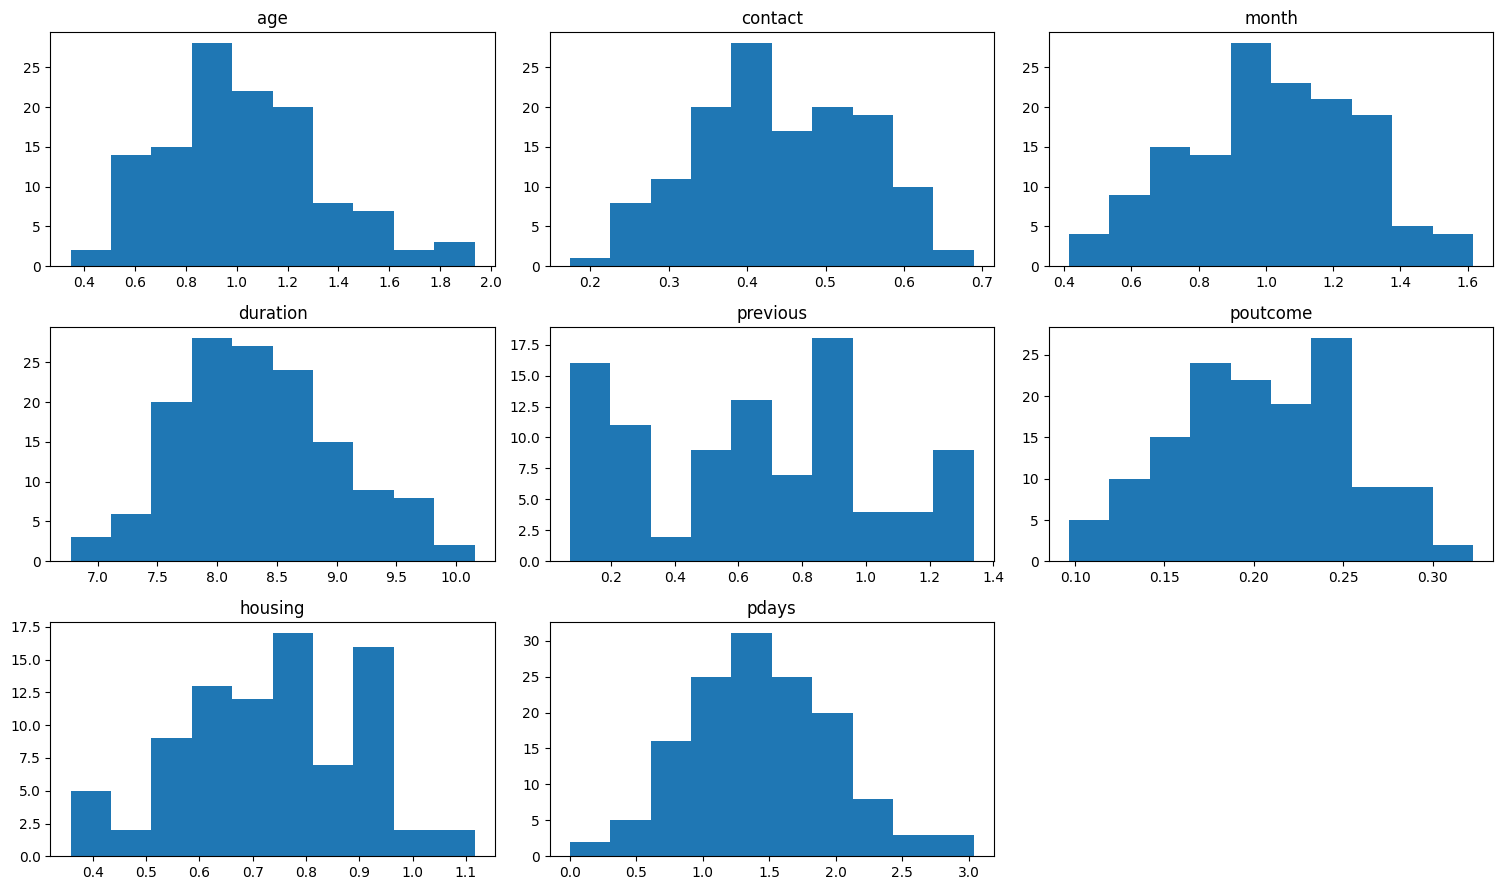

method: uniform_surface_ellipsoid_sampling, model_count: 108


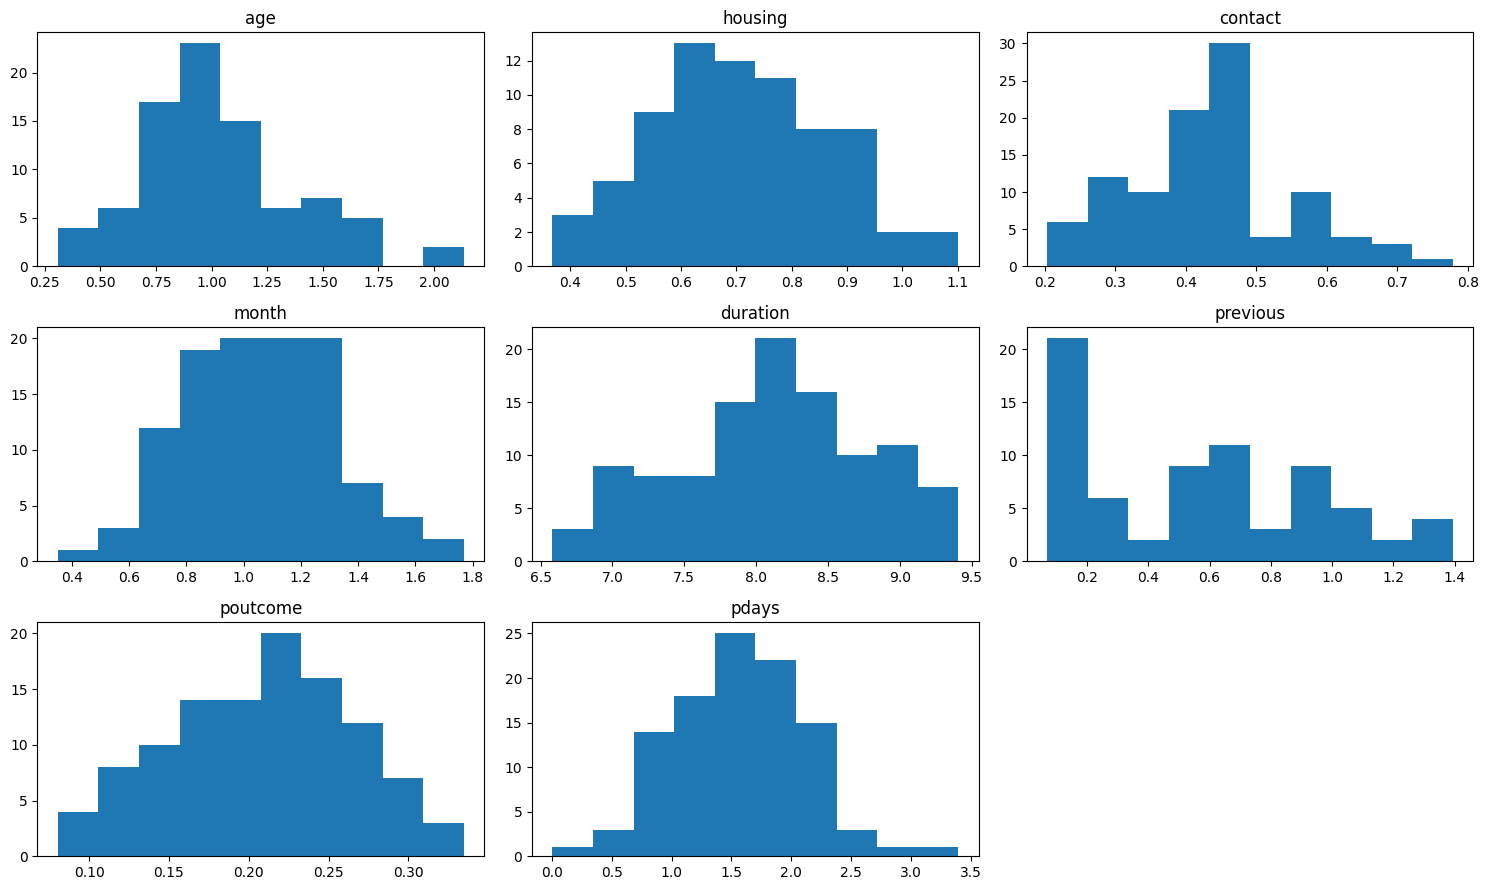

method: poisson__ellipsoid_sampling, model_count: 105


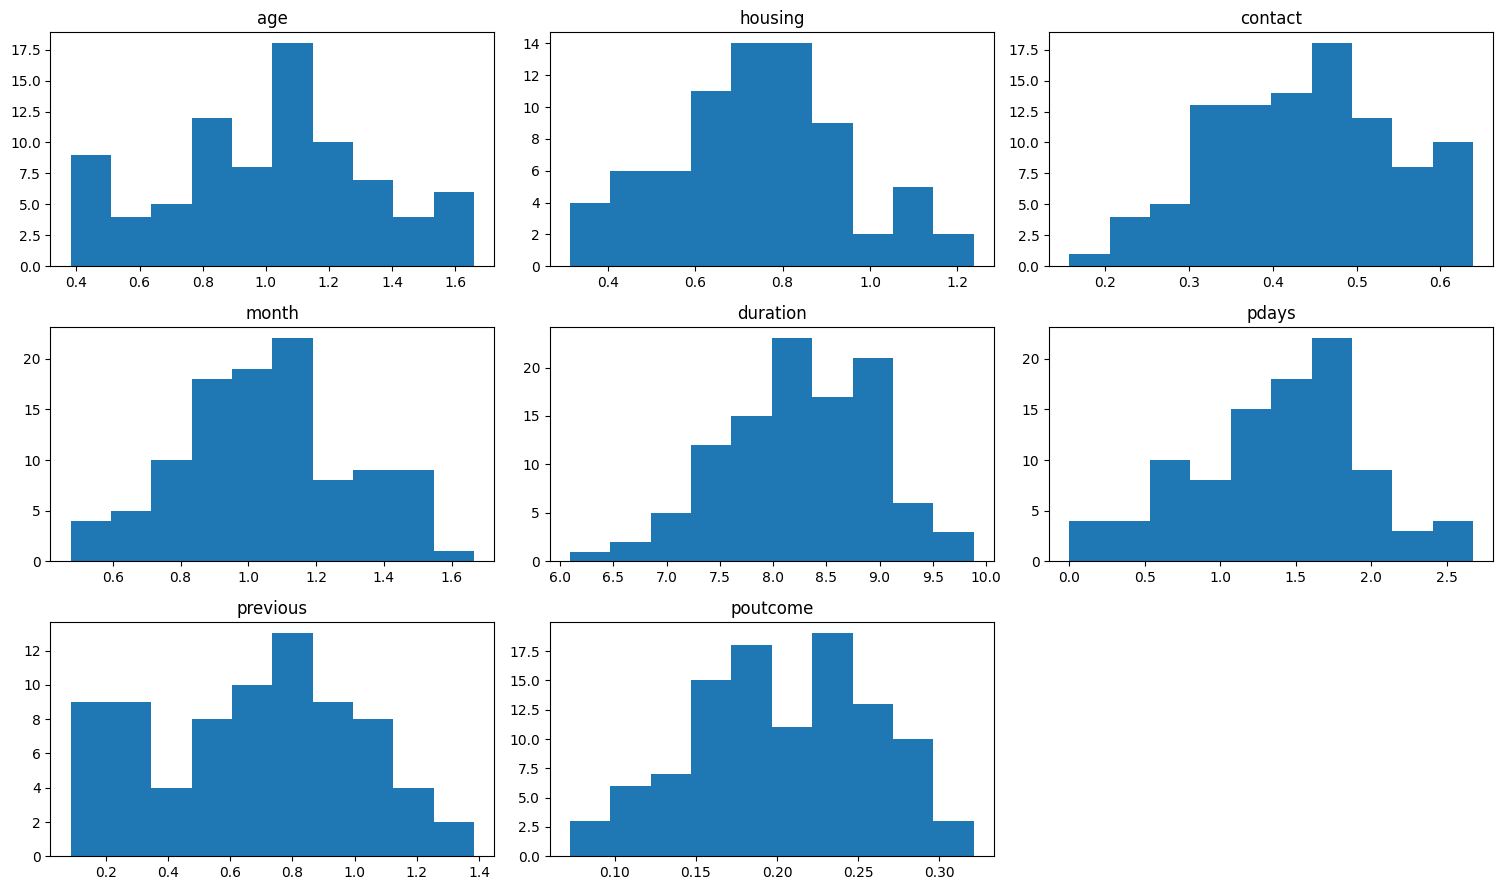

method: poisson_euclidean_ellipsoid_sampling, model_count: 150


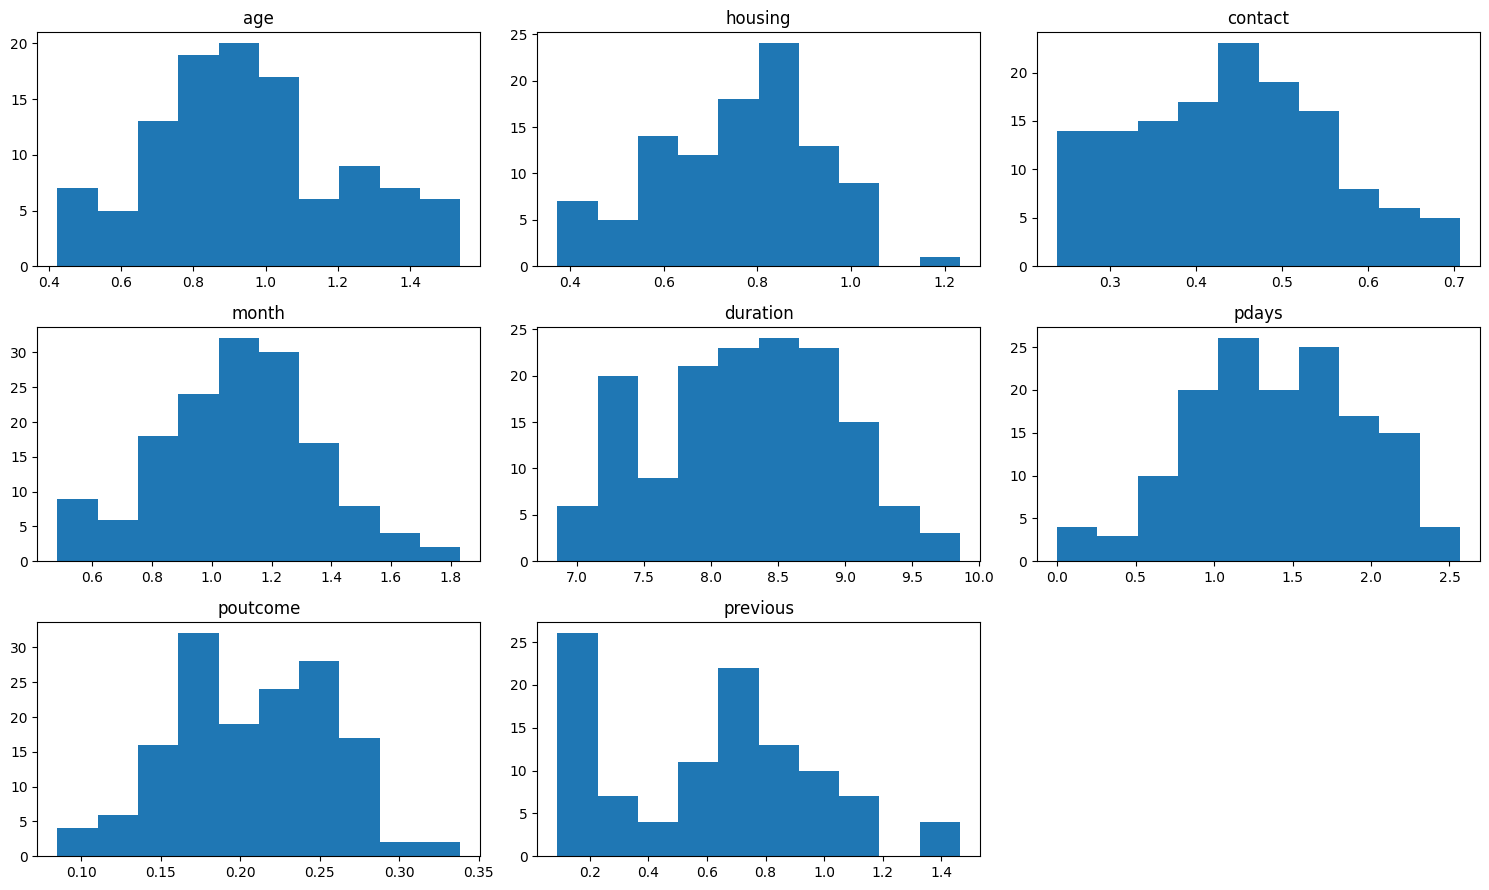

method: permutation__ellipsoid_sampling, model_count: 160


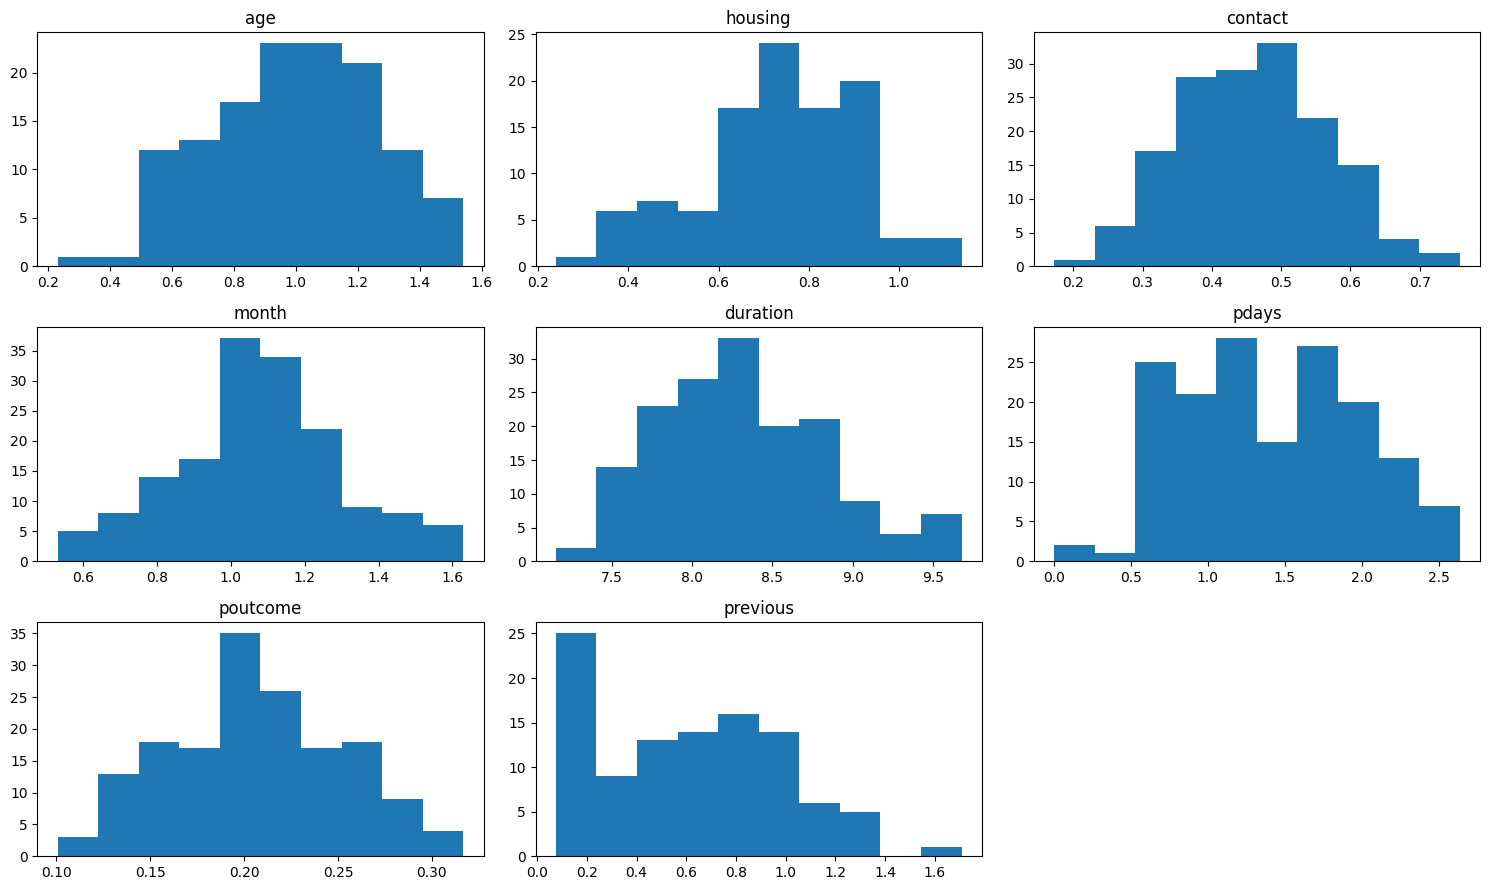

method: permutation_poisson_ellipsoid_sampling, model_count: 145


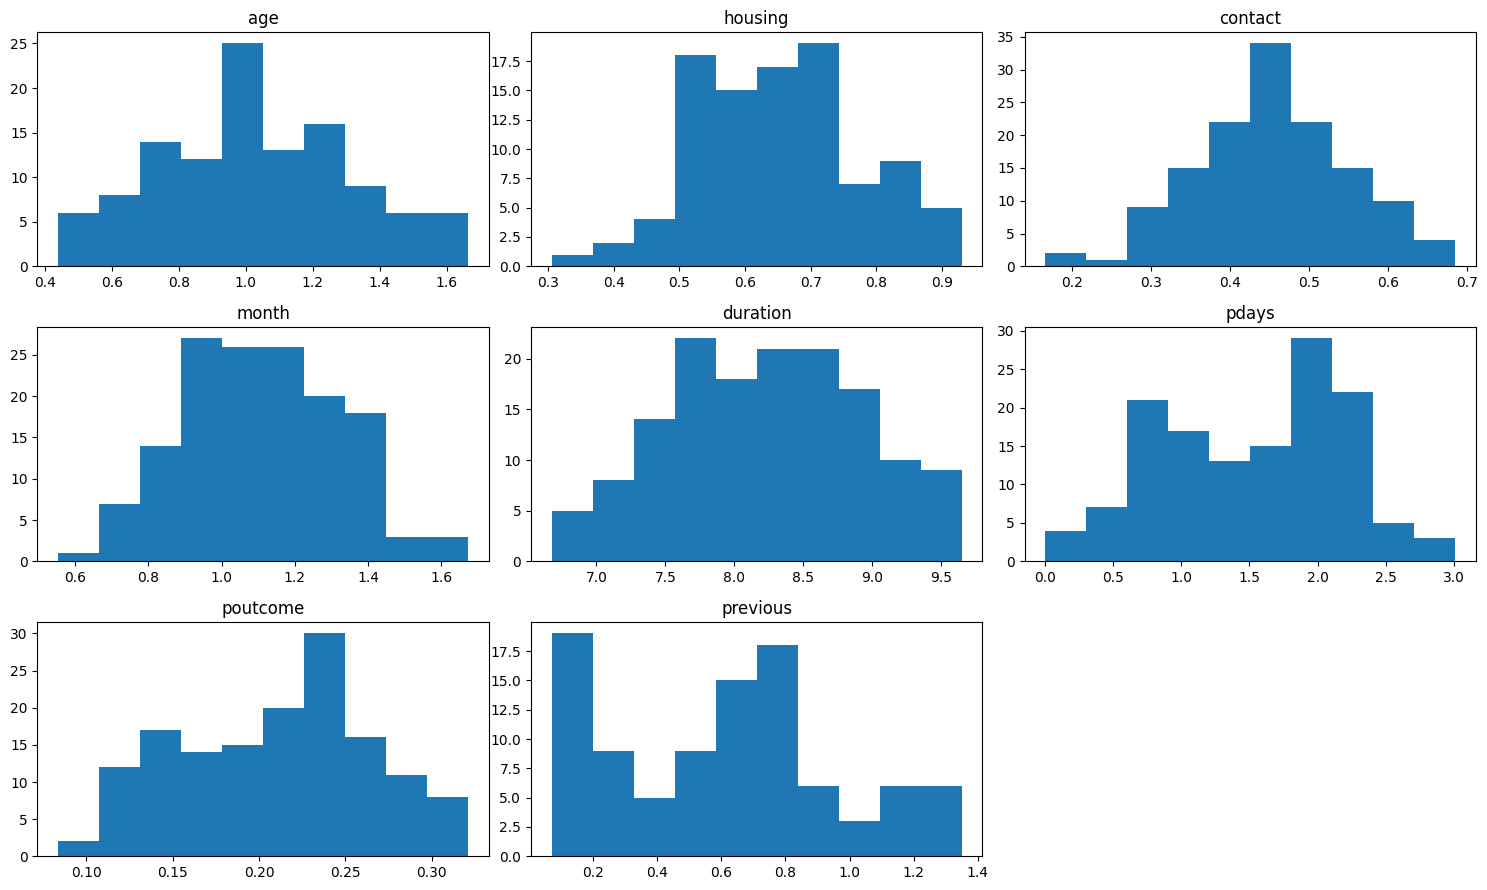

method: blocking, model_count: 100


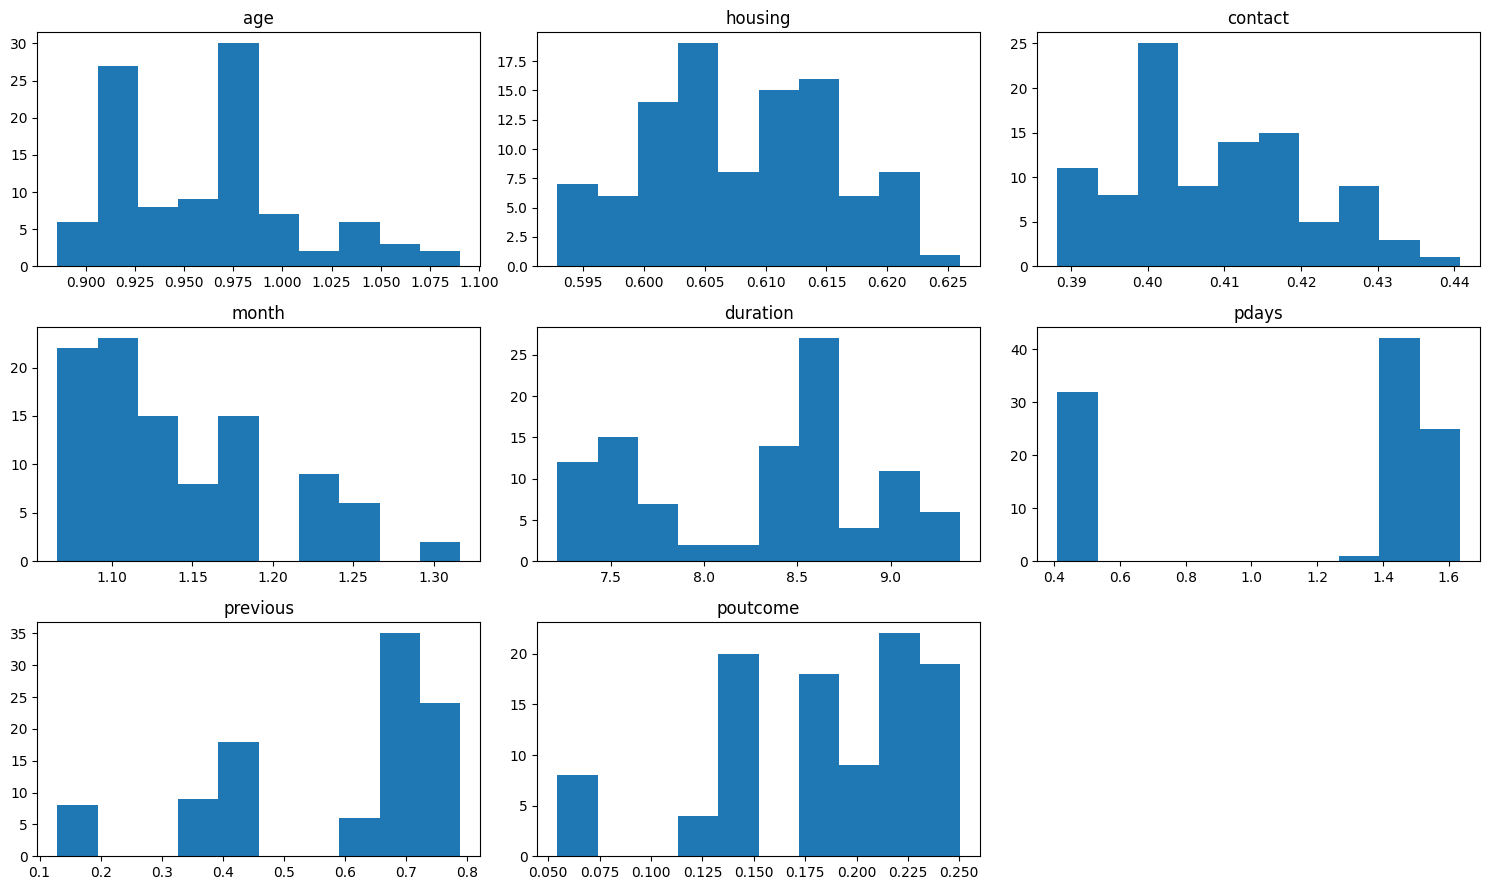

method: quadratic, model_count: 326


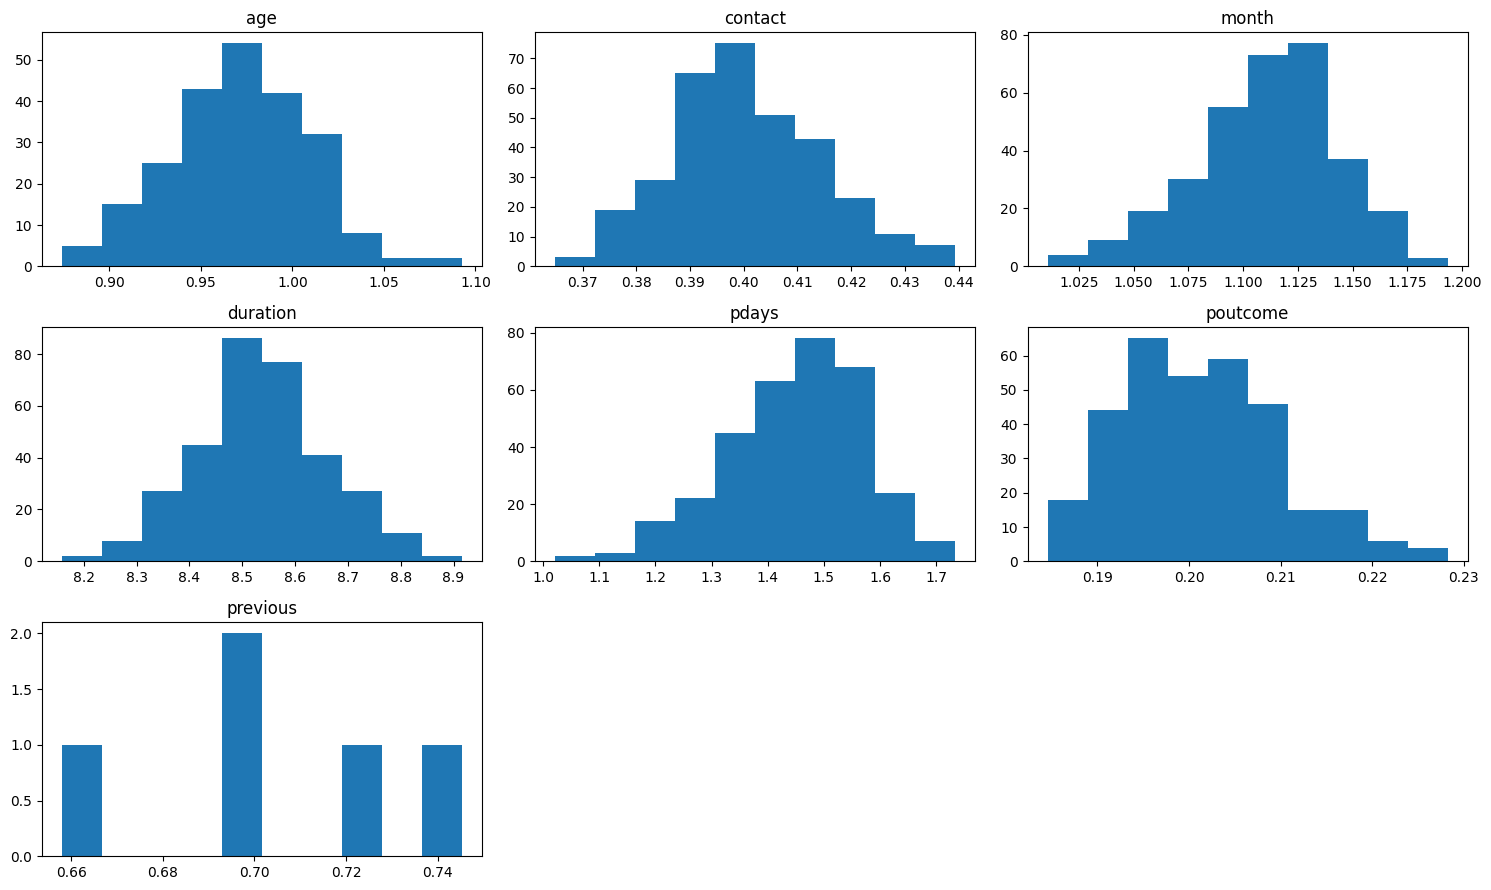

method: swapping, model_count: 204


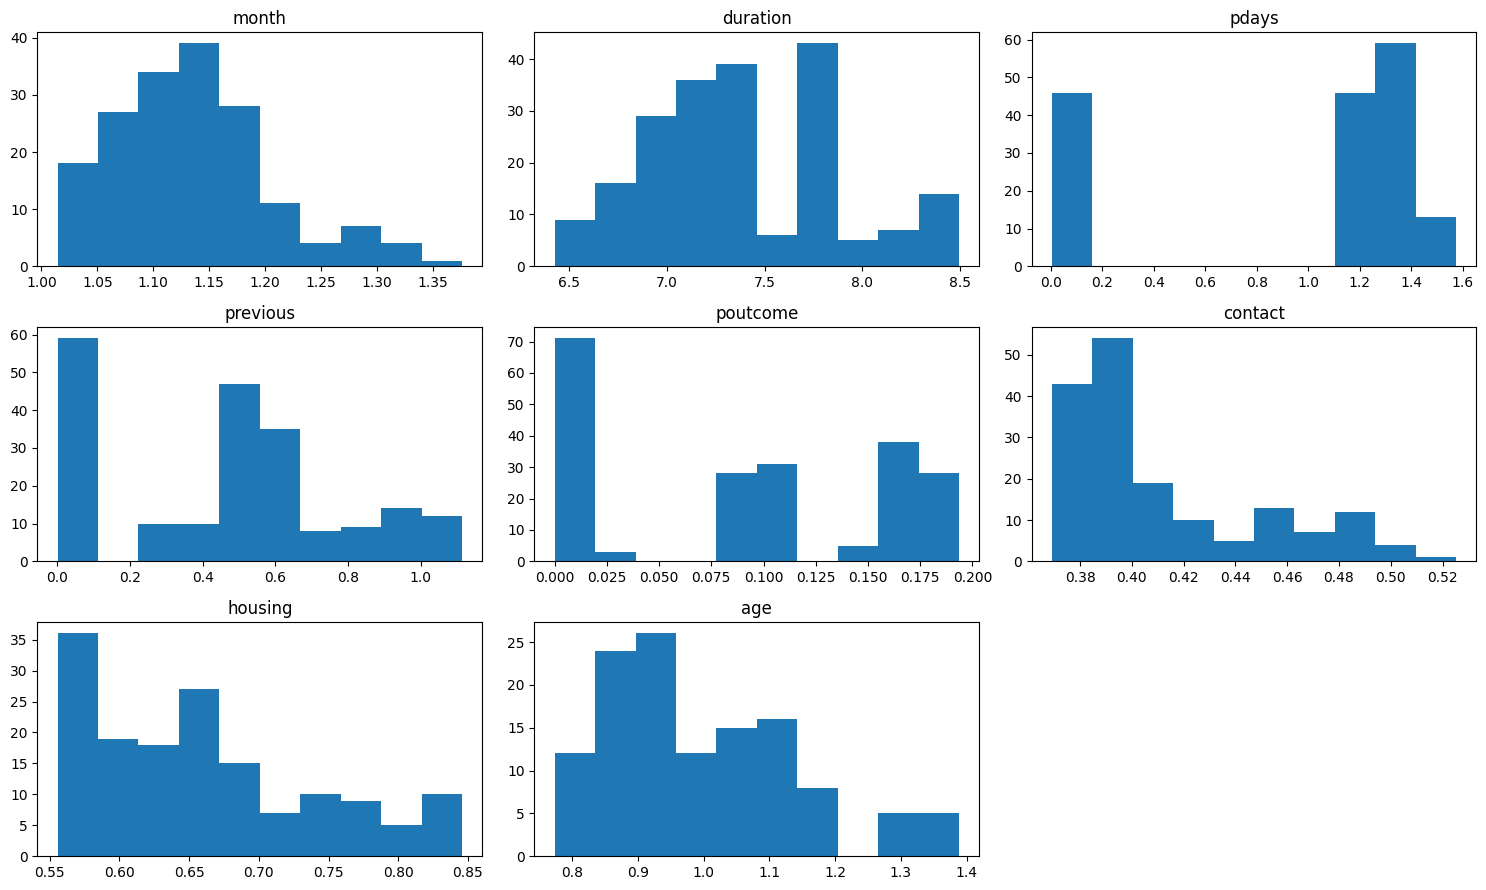

method: hybrid, model_count: 593


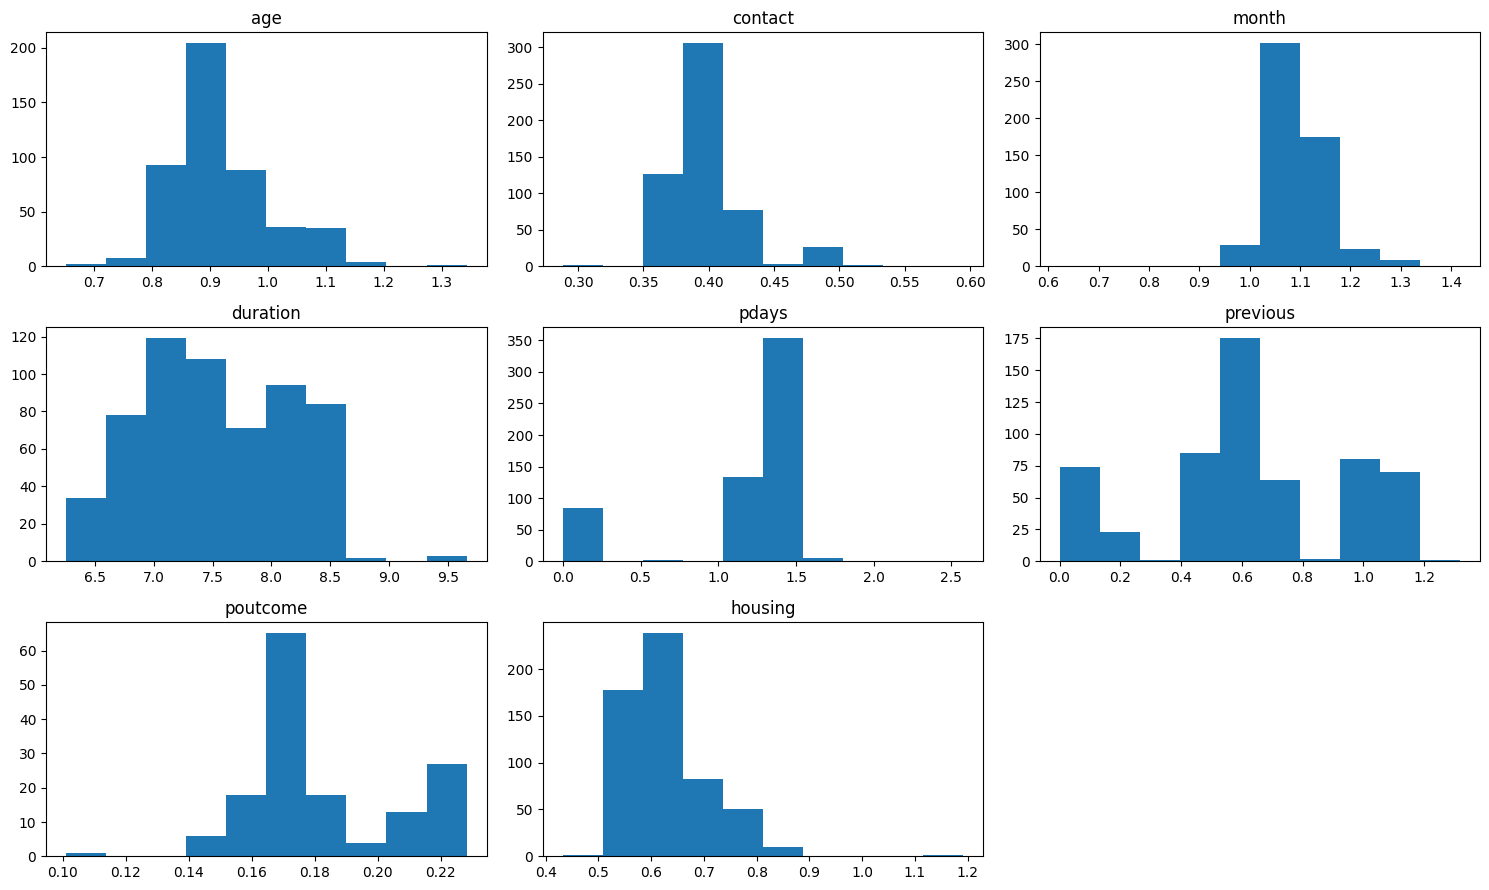

In [19]:
show_variable_importance(all_datasets_results, 'bank')

	uniform__ellipsoid_sampling: 1.6274811414174448 - 3.85389528179583
	uniform_surface_ellipsoid_sampling: 1.725263075043175 - 3.8701090439489163
	poisson__ellipsoid_sampling: 1.8377633040214416 - 4.1246549466559985
	poisson_euclidean_ellipsoid_sampling: 1.5921164816154934 - 3.666448010495332
	permutation__ellipsoid_sampling: 1.497102923650827 - 4.224860247466884
	permutation_poisson_ellipsoid_sampling: 2.836881038729034 - 3.472031515095604
	blocking: 2.7157123572849042 - 3.282554511298763
	quadratic: 2.3810883146514796 - 3.683089023458161
	swapping: 1.2377904053075965 - 3.408631343113901
	hybrid: 1.0333548514891255 - 3.3288725202706098


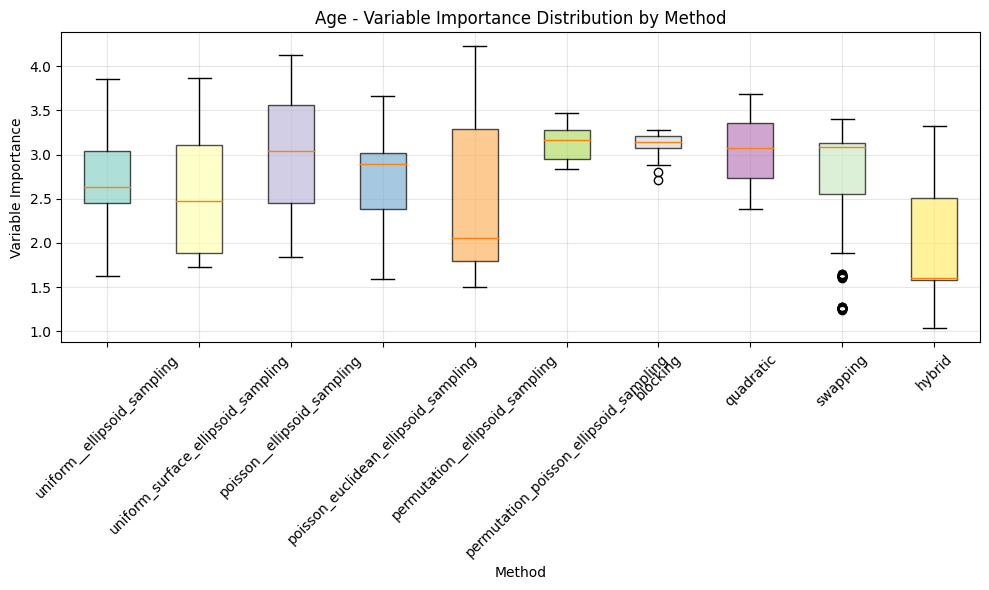

	uniform__ellipsoid_sampling: 0.7299632151616127 - 1.6639059720129237
	uniform_surface_ellipsoid_sampling: 0.7233220089831306 - 1.580256004459334
	poisson__ellipsoid_sampling: 0.7774308202743014 - 1.6924325367390167
	poisson_euclidean_ellipsoid_sampling: 0.8136441225904152 - 1.56207135451499
	permutation__ellipsoid_sampling: 0.6295166370035581 - 1.6643741092000226
	permutation_poisson_ellipsoid_sampling: 0.6447247483581157 - 1.309761173702434
	blocking: 0.9578377807833813 - 1.6422145728149877
	quadratic: 0.908747909377756 - 1.3875530111474148
	swapping: 0.038674349098767255 - 1.1857139765509754
	hybrid: 0.03797366626365211 - 1.215815491614112


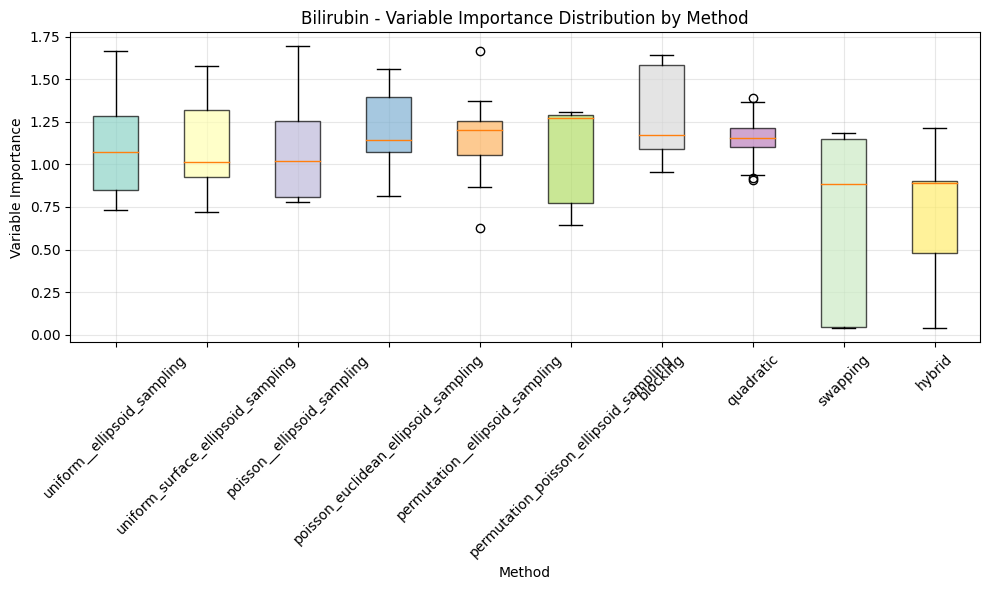

	uniform__ellipsoid_sampling: 0.020248313811886853 - 0.269797591487146
	uniform_surface_ellipsoid_sampling: 0.024730837076790916 - 0.32870181915716606
	poisson__ellipsoid_sampling: 0.023848301025911997 - 0.24806875717233415
	poisson_euclidean_ellipsoid_sampling: 0.0233517154010536 - 0.3424182437852051
	permutation__ellipsoid_sampling: 0.02493144226551325 - 0.4254579571126991
	permutation_poisson_ellipsoid_sampling: 0.025915488597403398 - 0.27875726318255184
	blocking: 0.21447009787927312 - 0.439709165187138
	quadratic: 0.030925779741454676 - 0.25489922103582224
	swapping: 0.025660033750179483 - 0.29260174341124473
	hybrid: 0.022940444121306133 - 0.30814459545396783


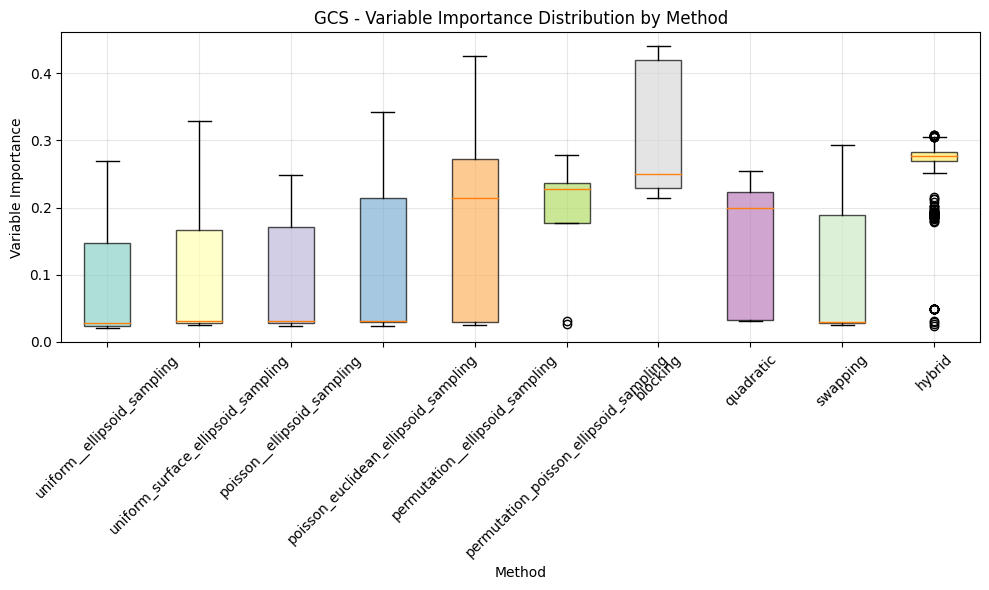

	uniform__ellipsoid_sampling: 0.013278294214940615 - 0.6437738128657924
	uniform_surface_ellipsoid_sampling: 0.013794620314752119 - 0.5367081355353731
	poisson__ellipsoid_sampling: 0.012696459302290793 - 0.658426362768163
	poisson_euclidean_ellipsoid_sampling: 0.013124972319787421 - 0.6541448668335703
	permutation__ellipsoid_sampling: 0.012173949748899786 - 0.6826339952076619
	permutation_poisson_ellipsoid_sampling: 0.010310786885229671 - 0.7327246059841861
	blocking: 0.3870173032243471 - 0.6840463141017719
	quadratic: 0.01726482347538197 - 0.49871778018717017
	swapping: 0.013624837125583144 - 0.4186018834715249
	hybrid: 0.010184484638225064 - 0.5903404371926224


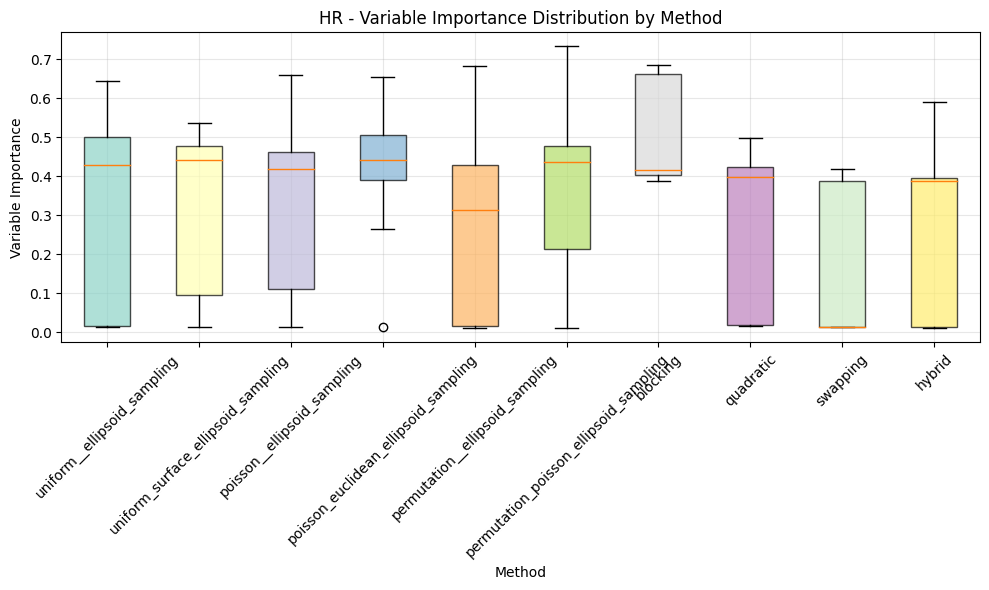

	uniform__ellipsoid_sampling: 0.010902874839135253 - 0.016019279884365467
	uniform_surface_ellipsoid_sampling: 0.00940337012859901 - 0.015781350067253324
	poisson__ellipsoid_sampling: 0.012615335498804857 - 0.014178040462777968
	poisson_euclidean_ellipsoid_sampling: 0.009480920732579565 - 0.014727843571664146
	permutation__ellipsoid_sampling: 0.010173794835953483 - 0.017243452038478792
	permutation_poisson_ellipsoid_sampling: 0.01144462961859639 - 0.016630971628679873
	blocking: 0.012861463218398645 - 0.013508523831618423
	quadratic: 0.01201480488483276 - 0.014158962446375156
	swapping: 0.012986592097385955 - 0.013782933685932478
	hybrid: 0.011470638815622375 - 0.013832100677783836


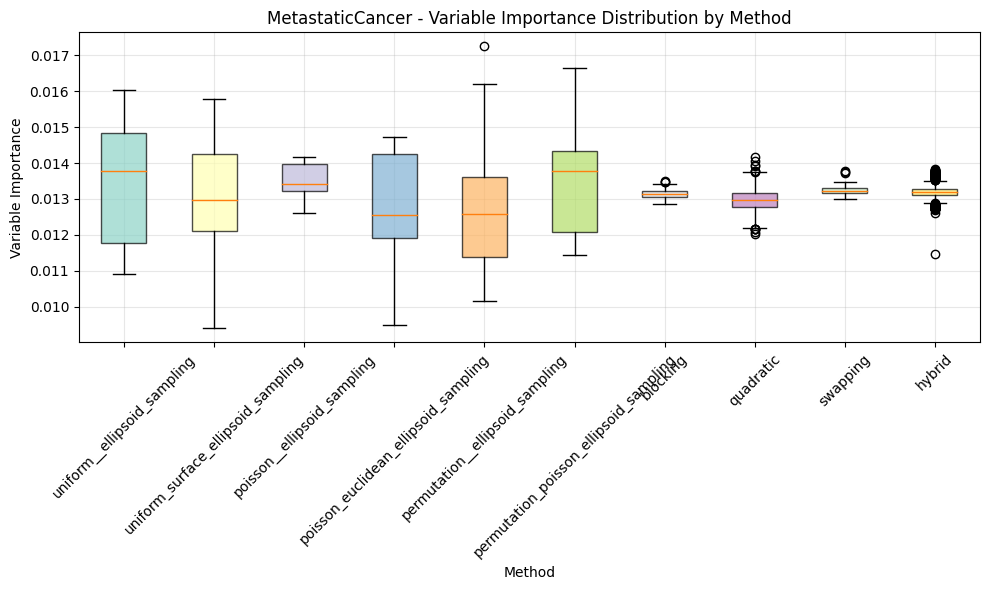

	uniform__ellipsoid_sampling: 0.16401638375102415 - 0.3097509746924563
	uniform_surface_ellipsoid_sampling: 0.14823613678383044 - 0.2830233581955314
	poisson__ellipsoid_sampling: 0.17461931869194963 - 0.30131626787057275
	poisson_euclidean_ellipsoid_sampling: 0.17848508869179391 - 0.2811122740367737
	permutation__ellipsoid_sampling: 0.1553430951136778 - 0.2681525655743112
	permutation_poisson_ellipsoid_sampling: 0.18199741136505715 - 0.24506036771729142
	blocking: 0.23774117535835568 - 0.2876958951046762
	quadratic: 0.19923898424810216 - 0.2648214364351575
	swapping: 0.11763157426250788 - 0.26863832683858985
	hybrid: 0.09842380058437189 - 0.2642026669589399


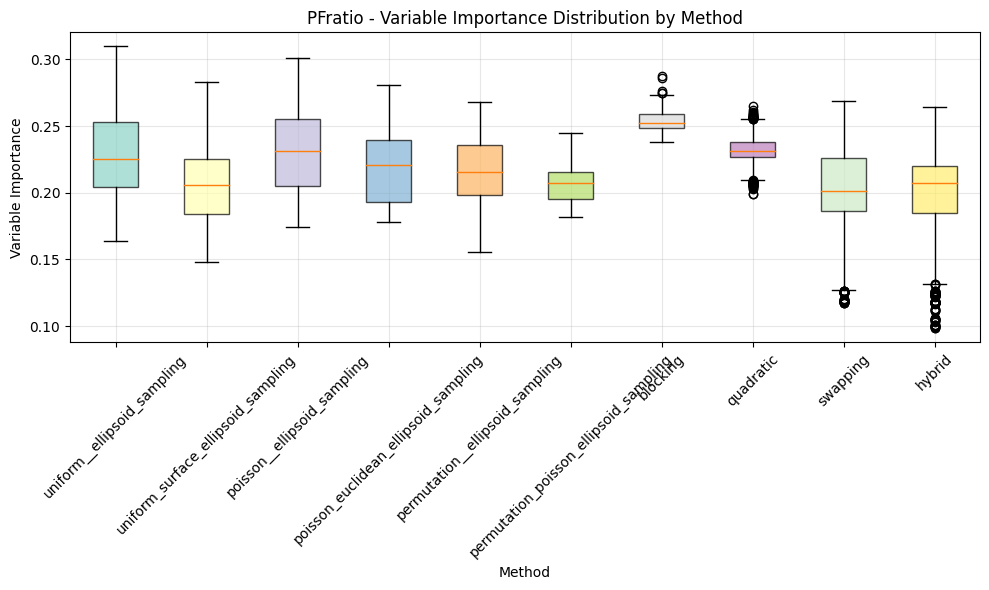

	uniform__ellipsoid_sampling: 0.45257293157649015 - 0.7670552285928847
	uniform_surface_ellipsoid_sampling: 0.5509890569471304 - 0.8493533713868675
	poisson__ellipsoid_sampling: 0.4148827869938806 - 0.7723152776882725
	poisson_euclidean_ellipsoid_sampling: 0.4125946281689998 - 0.8125919335053172
	permutation__ellipsoid_sampling: 0.5360734496089382 - 0.9203139554465976
	permutation_poisson_ellipsoid_sampling: 0.6240121626357233 - 0.8038440738381347
	blocking: 0.6091994059771587 - 0.7540336734247564
	quadratic: 0.5986826950013877 - 0.7123995581606687
	swapping: 0.4105269544530671 - 0.7146559173980165
	hybrid: 0.4149878308374136 - 0.7521718129785145


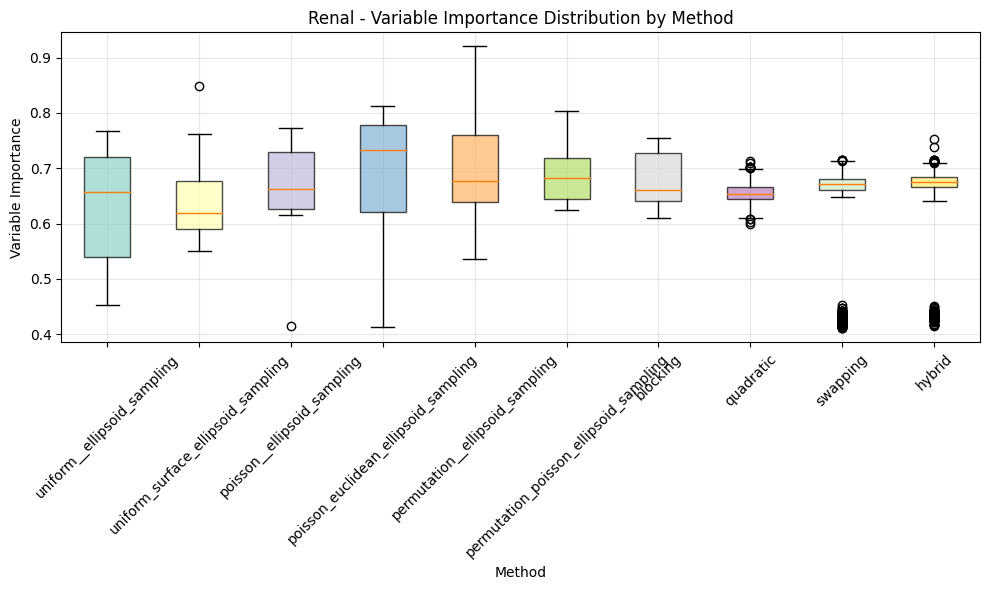

	uniform__ellipsoid_sampling: 0.05199152895613626 - 0.11299541966726025
	uniform_surface_ellipsoid_sampling: 0.051066491515958094 - 0.16857641502459078
	poisson__ellipsoid_sampling: 0.08755483174209681 - 0.136185758099229
	poisson_euclidean_ellipsoid_sampling: 0.06630047270485016 - 0.167964171409791
	permutation__ellipsoid_sampling: 0.05389658840332232 - 0.1561389836646636
	permutation_poisson_ellipsoid_sampling: 0.05129548496142754 - 0.11058821379412159
	blocking: 0.107420408804492 - 0.12829756031448475
	quadratic: 0.08798693946409258 - 0.11107452997190104
	swapping: 0.008278958176163616 - 0.12525567735672305
	hybrid: 0.007976860436296532 - 0.13969533335936585


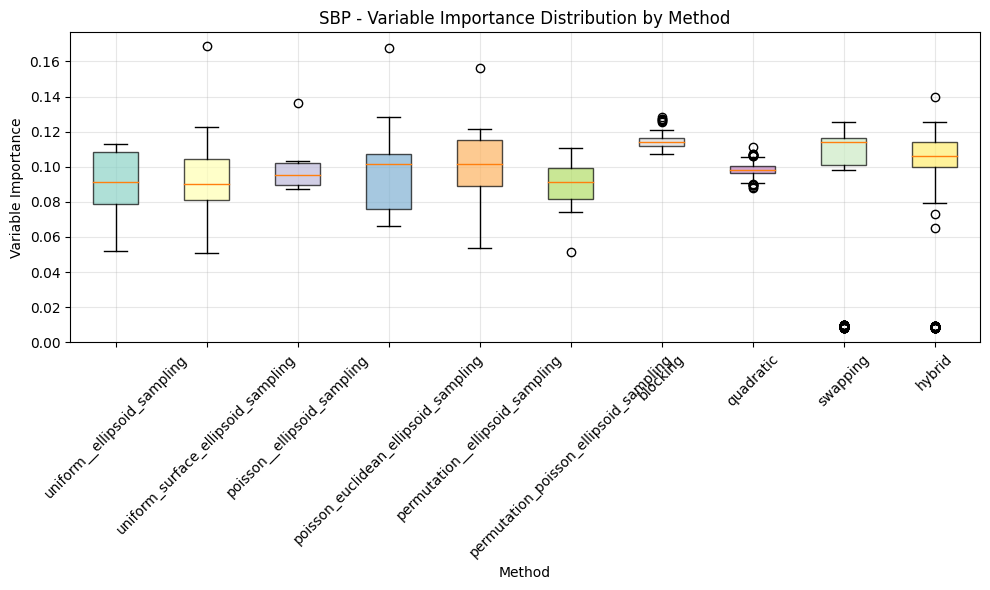

	uniform__ellipsoid_sampling: 0.033945917561317894 - 0.0718611789180328
	uniform_surface_ellipsoid_sampling: 0.030530790799128477 - 0.06560086417594796
	poisson__ellipsoid_sampling: 0.03947704238208002 - 0.05910210309082265
	poisson_euclidean_ellipsoid_sampling: 0.02655971406478266 - 0.0647788802049898
	permutation__ellipsoid_sampling: 0.030014994159645387 - 0.06828498020452542
	permutation_poisson_ellipsoid_sampling: 0.028513322059554355 - 0.07602095590900952
	blocking: 0.04345045034136442 - 0.047795464258870435
	quadratic: 0.03871068349677849 - 0.05047206452916582
	swapping: 0.04534280656071853 - 0.05097609653343788
	hybrid: 0.03510821366840365 - 0.050898554064193524


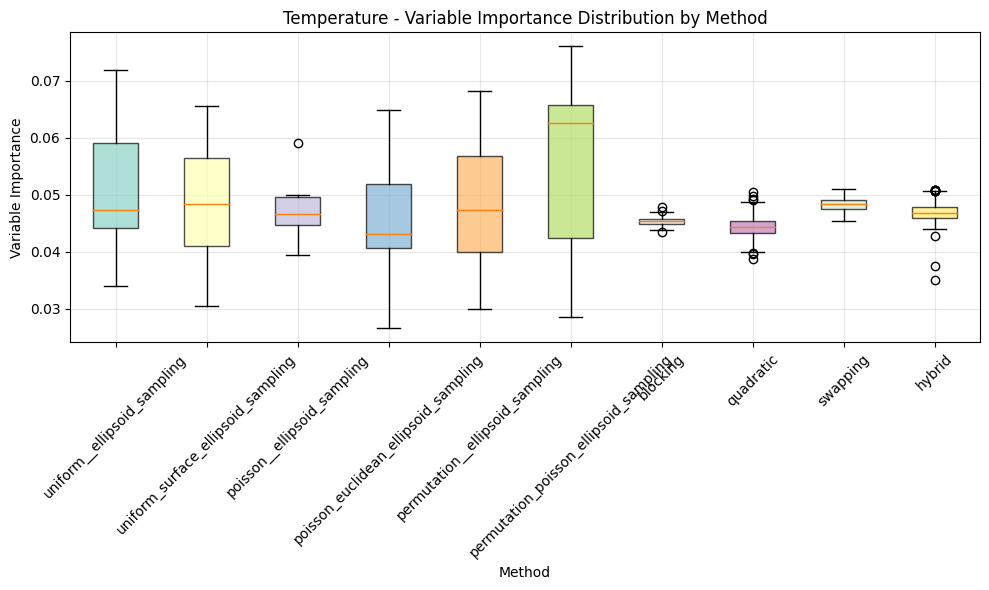

	uniform__ellipsoid_sampling: 0.027601105084327882 - 0.4877122263836962
	uniform_surface_ellipsoid_sampling: 0.025522268949898393 - 0.3144353092018395
	poisson__ellipsoid_sampling: 0.029861156100493978 - 0.06982117081392605
	poisson_euclidean_ellipsoid_sampling: 0.027067307195476 - 0.3139125322963186
	permutation__ellipsoid_sampling: 0.024385235677641802 - 0.20758738211919542
	permutation_poisson_ellipsoid_sampling: 0.026790306734103035 - 0.07137187985462183
	blocking: 0.15946703403963824 - 0.4142892400026961
	quadratic: 0.0322819950412646 - 0.0381725385329911
	swapping: 0.00016391870065314194 - 0.21970786903966077
	hybrid: 0.0001719423338027994 - 0.23367776768923515


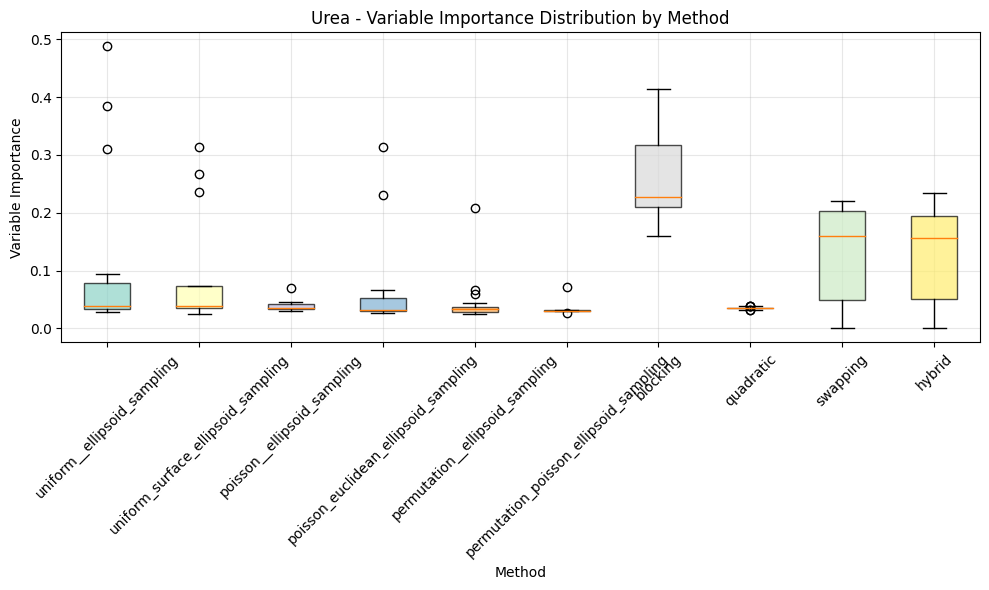

In [30]:
show_model_reliance(all_datasets_results, "mimic2")

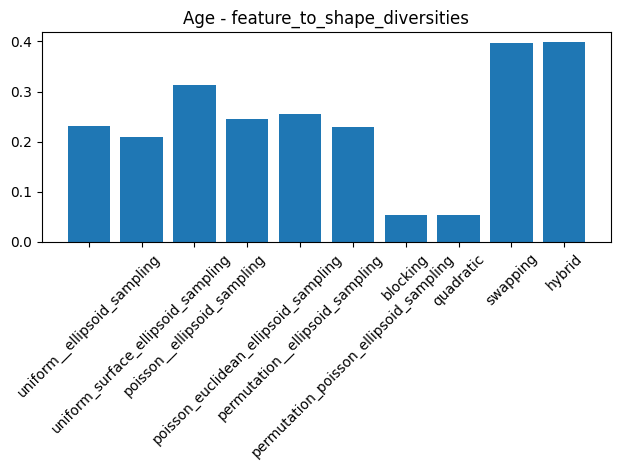

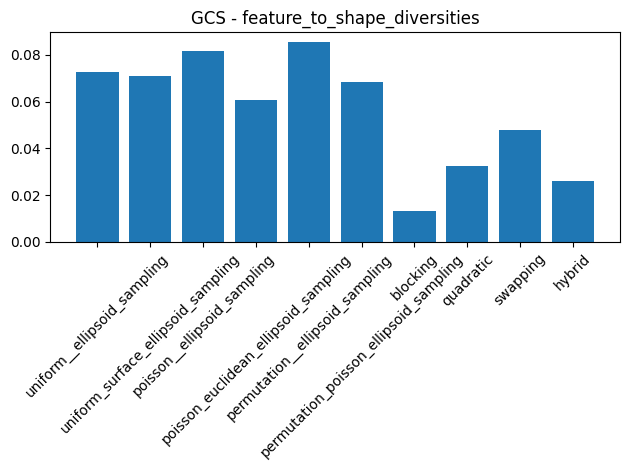

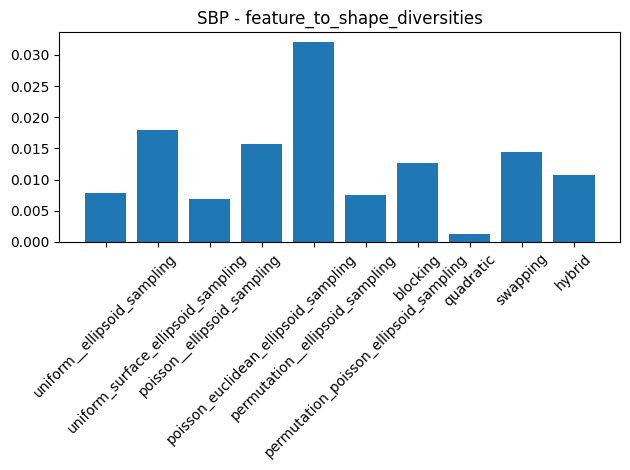

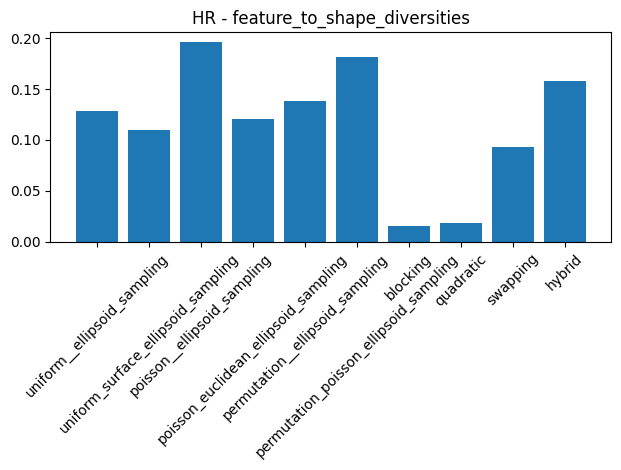

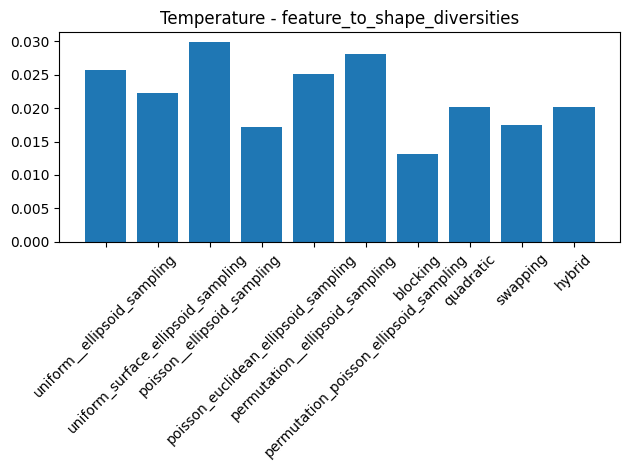

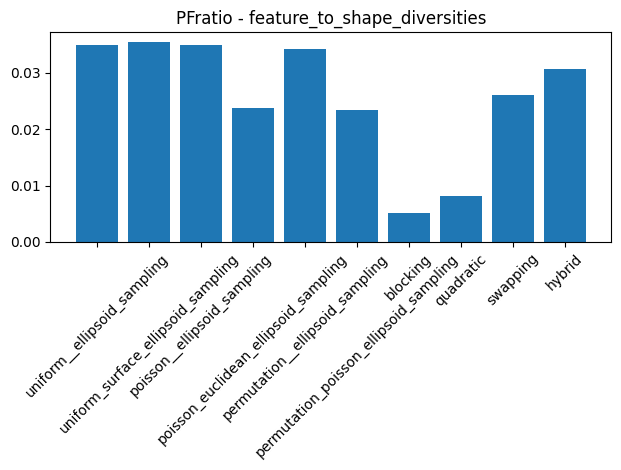

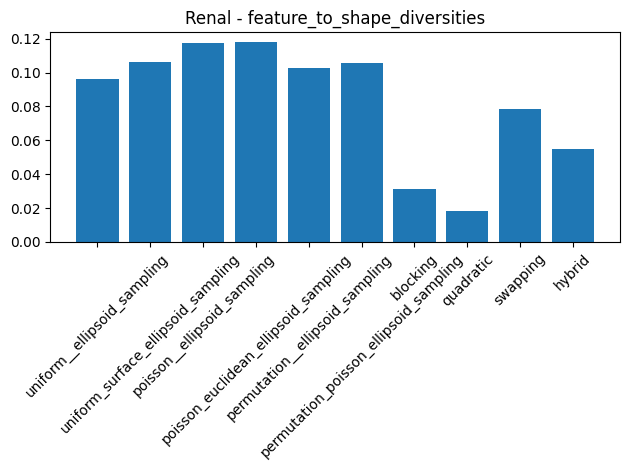

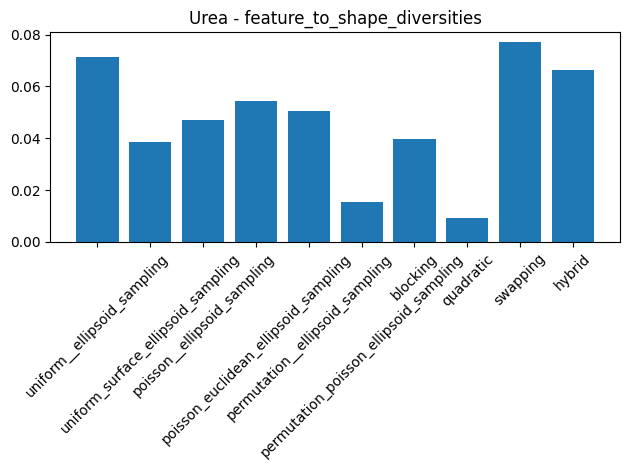

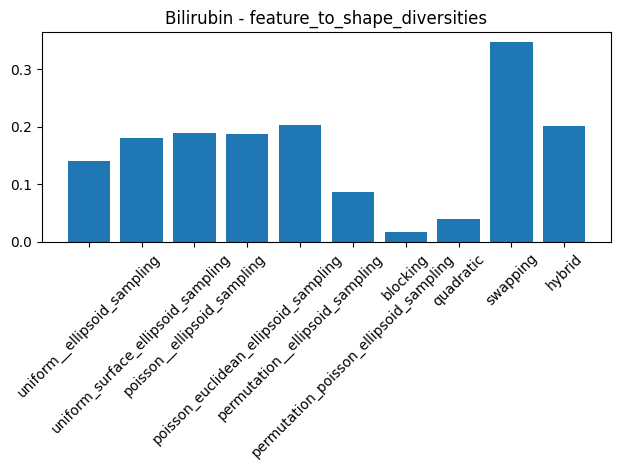

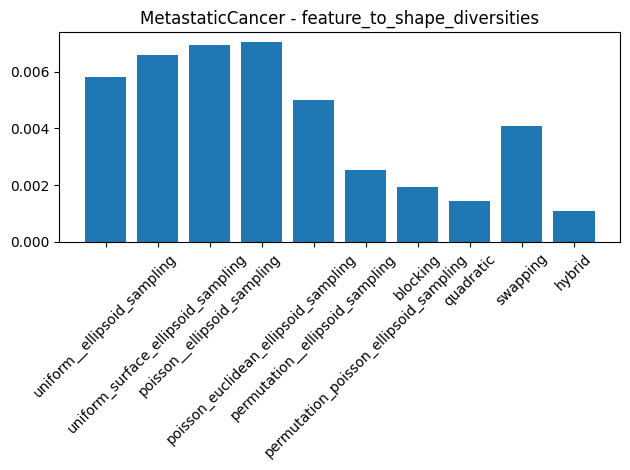

In [29]:
show_feature_to_shape_diversity(all_datasets_results, "mimic2", "feature_to_shape_diversities")